# Exploración de los datos

Mattia Riccardi - 202321259


Santiago Saede - 202321372

## Antes de empezar

### Requisitos para ejecutar este Notebook

Para garantizar la correcta ejecución del código y la reproducibilidad de los resultados, es necesario contar con un entorno de Python configurado con las dependencias indicadas a continuación.  
Se recomienda utilizar un **entorno virtual (venv)** para evitar conflictos de versiones.

---

### Versión de Python

Se recomienda utilizar:

- **Python ≥ 3.10**
- Probado en **Python 3.14**

---

### Librerías necesarias

Instalar las siguientes librerías antes de ejecutar el notebook:

```bash
pip install pandas numpy matplotlib seaborn scikit-learn statsmodels scipy openpyxl jinja2

## 1. Importar las librerías

In [231]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import numpy as np
import math

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn import set_config
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.formula.api import ols

from statsmodels.stats.diagnostic import linear_rainbow
from scipy.stats import ttest_1samp
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro


## 2. Cargar datos

Cargar los datos del csv

In [232]:
datos_pacientes = pd.read_csv('./data/Datos Lab 1.csv')

Trabajar sobre una copia de los datos

In [233]:
datos = datos_pacientes.copy()

Qué representan los datos compartidos

In [234]:
datos.head()

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Smoking Status,Diabetes Status,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,isDx5313,"November 08, 2023",M,44.0,114.300,1.720,38.600,100.000,112/83,228.0,77.0,91.0,Y,Y,High,N,172.000,0.581,112.0,83.0,Hypertension Stage 1,121.0,19.880,HIGH
1,LHCK2961,20/03/2024,F,57.0,92.923,1.842,33.116,106.315,101/91,158.0,71.0,76.0,N,Y,High,Y,184.172,0.577,101.0,91.0,Hypertension Stage 2,57.0,16.833,INTERMEDIARY
2,WjVn1699,2021-05-27,F,NaN,73.400,1.650,27.000,78.100,90/74,135.0,60.0,150.0,N,N,High,N,165.000,0.473,90.0,74.0,Normal,45.0,12.600,LOW
3,dCDO1109,"April 18, 2022",F,35.0,113.300,1.780,35.800,79.600,92/89,158.0,34.0,111.0,Y,N,Moderate,Y,178.000,0.447,92.0,89.0,Hypertension Stage 1,94.0,14.920,HIGH
4,pnpE1080,01/11/2024,F,48.0,102.200,1.750,33.400,106.700,121/68,207.0,49.0,147.0,Y,Y,Low,Y,175.000,0.610,121.0,68.0,Elevated,128.0,18.870,HIGH


## 3. Perfilamiento

Se usa la función head() para tomar una muestra de los primero datos y obtener una visión inicial.

In [235]:
pd.set_option('display.max_columns', None)
datos.head()

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Smoking Status,Diabetes Status,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,isDx5313,"November 08, 2023",M,44.0,114.300,1.720,38.600,100.000,112/83,228.0,77.0,91.0,Y,Y,High,N,172.000,0.581,112.0,83.0,Hypertension Stage 1,121.0,19.880,HIGH
1,LHCK2961,20/03/2024,F,57.0,92.923,1.842,33.116,106.315,101/91,158.0,71.0,76.0,N,Y,High,Y,184.172,0.577,101.0,91.0,Hypertension Stage 2,57.0,16.833,INTERMEDIARY
2,WjVn1699,2021-05-27,F,NaN,73.400,1.650,27.000,78.100,90/74,135.0,60.0,150.0,N,N,High,N,165.000,0.473,90.0,74.0,Normal,45.0,12.600,LOW
3,dCDO1109,"April 18, 2022",F,35.0,113.300,1.780,35.800,79.600,92/89,158.0,34.0,111.0,Y,N,Moderate,Y,178.000,0.447,92.0,89.0,Hypertension Stage 1,94.0,14.920,HIGH
4,pnpE1080,01/11/2024,F,48.0,102.200,1.750,33.400,106.700,121/68,207.0,49.0,147.0,Y,Y,Low,Y,175.000,0.610,121.0,68.0,Elevated,128.0,18.870,HIGH


También se pueden observar datos aleatorios del dataset para asegurarse que otras posiciones cumplen con el formato. 

In [236]:
display(datos.sample(10))

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Smoking Status,Diabetes Status,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
1363,WVxJ0254,07-01-2020,F,70.0,58.350,1.542,23.761,100.617,95/110,-1.256,37.0,119.0,Y,N,Moderate,Y,154.185,NaN,95.0,110.0,Hypertension Stage 2,64.0,12.122,INTERMEDIARY
1154,qCVA5701,"April 08, 2021",F,30.0,116.400,1.640,43.300,109.400,124/65,198.000,39.0,148.0,Y,Y,High,Y,164.000,0.667,124.0,NaN,Elevated,129.0,20.820,HIGH
1512,loec3298,08-03-2025,M,63.0,110.797,1.768,32.759,84.932,149/80,192.000,69.0,146.0,Y,Y,Low,Y,176.768,0.480,149.0,80.0,Hypertension Stage 1,93.0,19.842,INTERMEDIARY
652,SKRd0515,2023-09-28,F,NaN,100.600,1.600,39.300,NaN,91/66,298.000,60.0,76.0,Y,N,Moderate,Y,160.000,0.545,91.0,66.0,Normal,208.0,18.370,HIGH
632,aIHb6581,27/09/2020,F,46.0,65.700,1.770,21.000,77.100,129/78,232.000,59.0,113.0,N,Y,High,N,177.000,0.436,129.0,78.0,Elevated,143.0,17.290,INTERMEDIARY
278,wFdM7237,02 May 20,F,46.0,71.400,1.790,22.300,104.400,122/80,NaN,64.0,88.0,Y,Y,Low,N,179.000,0.583,122.0,80.0,Hypertension Stage 1,67.0,15.780,HIGH
21,HDXx4497,2020-09-13,F,NaN,118.500,1.770,37.800,91.700,121/84,185.000,30.0,123.0,N,Y,Low,N,177.000,0.518,121.0,84.0,Hypertension Stage 1,125.0,19.310,HIGH
663,QygN1471,28/08/2020,M,49.0,62.814,1.836,23.749,98.415,150/81,254.000,44.0,143.0,Y,Y,Low,Y,183.640,0.536,150.0,81.0,Hypertension Stage 1,180.0,19.330,HIGH
684,qoOw6598,16 Apr 23,F,60.0,116.200,NaN,36.700,97.800,112/80,188.000,52.0,97.0,Y,N,Moderate,N,NaN,0.549,112.0,80.0,Hypertension Stage 1,106.0,16.700,INTERMEDIARY
85,Ppoi3297,25 Sep 20,F,NaN,110.200,1.770,35.200,102.000,92/100,247.000,67.0,106.0,Y,N,High,Y,177.000,0.576,92.0,100.0,Hypertension Stage 2,150.0,16.580,HIGH


Usando datos.shape se puede conocer información general sobre la cantidad de registros y variables:

In [237]:
datos.shape

(1639, 24)

Existen 1639 registros. Para cada uno de esos registros hay 24 variables que se deben tener en cuenta. 

Para saber información específica sobre el tipo de dato de cada una de las variables se puede hacer lo siguiente:

In [238]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 1639 entries, 0 to 1638
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient ID                    1639 non-null   str    
 1   Date of Service               1639 non-null   str    
 2   Sex                           1639 non-null   str    
 3   Age                           1571 non-null   float64
 4   Weight (kg)                   1566 non-null   float64
 5   Height (m)                    1578 non-null   float64
 6   BMI                           1586 non-null   float64
 7   Abdominal Circumference (cm)  1578 non-null   float64
 8   Blood Pressure (mmHg)         1639 non-null   str    
 9   Total Cholesterol (mg/dL)     1571 non-null   float64
 10  HDL (mg/dL)                   1557 non-null   float64
 11  Fasting Blood Sugar (mg/dL)   1585 non-null   float64
 12  Smoking Status                1639 non-null   str    
 13  Diabetes Statu

Ahora sabemos que la mayoría de los datos son de tipo float. Aún así, hay bastantes datos que son de tipo string. Adicionalmente, podemos ver que la mayoría de variables contienen registros nulos. La mayoría no son nulos, igualmente es una cantidad que se debe tener en cuenta. 

Para conocer más sobre el tipo de información se va a acceder al diccionario de los datos:

In [239]:
diccionario_datos = pd.read_excel('./data/DiccPacientes.xlsx')
pd.set_option('display.max_colwidth', None)
diccionario_datos

,Nombre Columna,Tipo de dato,Comentarios
0,Patient ID,String,Identificador del paciente
1,Date of Service,Date,Fecha de la atención
2,Sex,String,"Sexo (Femenino, Masculino)"
3,Age,Integer,Edad
4,Weight (kg),Float,Peso
5,Height (m),Float,Altura
6,BMI,Float,Índice de masa corporal
7,Abdominal Circumference (cm),Float,Circunferencia abdominal
8,Blood Pressure (mmHg),String,"Presión sanguínea, de la forma ""<Presión arterial sistólica>/<Presión arterial diastólica>"""
9,Total Cholesterol (mg/dL),Float,Colesterol total


Combinando esto con la información que encontramos con datos.info(), podemos tener más contexto sobre cada variable diferente y entender por qué cada variable es el tipo que es. Además, acá se puede ver que hay algunas diferencias con el tipo de dato que sale en el diccionario vs el tipo que sale cuando se usa la función info(). 

En específico, unas variables que dicen tipo string según info(), dice que son booleanas o date según el diccionario. En el caso de las que dicen float en info(), algunas son integer en el diccionario.

Para entender aún mejor, se va a usar la función describe():

In [240]:
pd.set_option('display.max_columns', None)
datos.describe()

,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL),CVD Risk Score
count,1571.000000,1566.000000,1578.000000,1586.000000,1578.000000,1571.000000,1557.000000,1585.000000,1571.000000,1563.000000,1578.000000,1554.000000,1582.000000,1610.000000
mean,46.803186,85.666006,1.757439,28.424744,91.538861,199.043673,56.183558,117.836860,175.770082,0.522440,125.632637,82.887536,113.235896,18.227281
std,13.039479,21.712504,0.118012,7.309275,13.427985,59.388670,16.721702,32.379634,11.695880,0.085692,22.577463,15.503625,61.435291,10.767666
min,6.134000,13.261000,1.371000,4.317000,49.542000,-1.256000,0.008000,15.306000,136.498000,0.250000,49.914000,31.720000,-92.055000,-20.057000
25%,37.000000,67.100000,1.666500,22.600000,79.700000,150.000000,42.000000,92.000000,167.000000,0.453000,108.000000,71.000000,62.000000,15.150000
50%,46.000000,86.314000,1.760000,28.000000,91.200000,199.000000,56.000000,115.000000,176.000000,0.519000,125.000000,82.000000,112.000000,16.967000
75%,55.000000,104.801500,1.850000,33.963000,102.267250,250.000000,70.000000,139.000000,185.000000,0.582000,141.000000,93.000000,159.000000,18.900000
max,89.420000,158.523000,2.146000,53.028000,136.336000,385.679000,110.315000,219.667000,214.394000,0.804000,202.711000,134.066000,317.314000,114.980000


Obervando los datos de esta manera permite generar conclusiones más específicas sobre las tendencias y otros elementos notables dentro de los datos. Estas son algunas de las conclusiones:
- La mayoría de las personas en los datos tienden a ser adultos alrededor de los 45. Aún así, el rango va de 6 a 81.
- Se puede ver que los pesos de las personas tienden a ser bastante alto. Esto puede indicar posibles hábitos de nutrición dentro de la población estudiada. 
- El BMI y el nivel de colesterol tiene sentido si se analiza junto a los pesos, que tienden a ser un poco altos.
- Algunas variables tienen valores extraños. Por ejemplo, el colesterol total tiene al menos un valor negativo, lo cual es imposible. Lo mismo sucede con HDL y riesgo cardiovascular.
- Existe altura tanto en metros como en centímetros. Esto es redundante y en algunos casos los datos se contradicen ligeramente.

En general, los datos tiened a mostrar una población donde existe un alto riesgo cardiovascular por sobrepeso, reflejado por las tendencias altas en las variables que indican esto. 

# Primer modelo:

## 1. Corregir los problemas de calidad de datos

### Completitud

Detección de datos faltantes

In [241]:
pd.DataFrame({
    "faltantes": datos.isnull().sum(),
    "porcentaje_%": (datos.isnull().sum() / len(datos) * 100).round(2)
})

,faltantes,porcentaje_%
Patient ID,0,0.00
Date of Service,0,0.00
Sex,0,0.00
Age,68,4.15
Weight (kg),73,4.45
Height (m),61,3.72
BMI,53,3.23
Abdominal Circumference (cm),61,3.72
Blood Pressure (mmHg),0,0.00
Total Cholesterol (mg/dL),68,4.15


#### Correcciones a partir de fórmulas matemáticas

##### BMI, Height y Weight

Partiendo de que BMI = Weight (kg) / (Height (m))^2

Detectar casos donde falta Height pero hay Weight y BMI

In [242]:
condicion = (
    datos["Height (m)"].isna() &
    datos["Weight (kg)"].notna() &
    datos["BMI"].notna()
)

datos[condicion].head()

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Smoking Status,Diabetes Status,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
81,NBUl2902,01-21-2025,F,62.0,87.544,NaN,38.527,86.487,154/60,125.0,48.0,167.0,Y,Y,Moderate,Y,178.337,0.485,154.0,60.0,Hypertension Stage 2,47.0,19.905,HIGH
152,XZCU4466,22/01/2024,F,52.0,97.800,NaN,31.600,94.800,124/92,216.0,50.0,101.0,N,Y,High,N,176.000,0.539,124.0,92.0,Hypertension Stage 2,136.0,18.840,HIGH
155,SdtW2617,21/06/2021,M,NaN,115.400,NaN,36.800,91.900,142/64,NaN,39.0,118.0,Y,Y,High,N,177.000,0.519,142.0,64.0,Hypertension Stage 2,67.0,19.180,HIGH
162,QoLE0357,24 Jun 25,F,42.0,84.600,NaN,30.300,77.900,104/62,236.0,70.0,126.0,N,Y,High,Y,167.000,0.466,104.0,62.0,Normal,136.0,30.840,HIGH
196,EsZI4603,"July 03, 2020",F,79.0,110.631,NaN,19.288,102.272,176/89,261.0,56.0,75.0,Y,Y,High,Y,174.123,0.587,NaN,NaN,Hypertension Stage 1,175.0,19.878,LOW


Recalcular Height en esos casos

In [243]:
datos.loc[condicion, "Height (m)"] = np.sqrt(
    datos.loc[condicion, "Weight (kg)"] /
    datos.loc[condicion, "BMI"]
)
datos[condicion].head()

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Smoking Status,Diabetes Status,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
81,NBUl2902,01-21-2025,F,62.0,87.544,1.507407,38.527,86.487,154/60,125.0,48.0,167.0,Y,Y,Moderate,Y,178.337,0.485,154.0,60.0,Hypertension Stage 2,47.0,19.905,HIGH
152,XZCU4466,22/01/2024,F,52.0,97.800,1.759243,31.600,94.800,124/92,216.0,50.0,101.0,N,Y,High,N,176.000,0.539,124.0,92.0,Hypertension Stage 2,136.0,18.840,HIGH
155,SdtW2617,21/06/2021,M,NaN,115.400,1.770839,36.800,91.900,142/64,NaN,39.0,118.0,Y,Y,High,N,177.000,0.519,142.0,64.0,Hypertension Stage 2,67.0,19.180,HIGH
162,QoLE0357,24 Jun 25,F,42.0,84.600,1.670952,30.300,77.900,104/62,236.0,70.0,126.0,N,Y,High,Y,167.000,0.466,104.0,62.0,Normal,136.0,30.840,HIGH
196,EsZI4603,"July 03, 2020",F,79.0,110.631,2.394941,19.288,102.272,176/89,261.0,56.0,75.0,Y,Y,High,Y,174.123,0.587,NaN,NaN,Hypertension Stage 1,175.0,19.878,LOW


Hacer lo mismo si falta Weight

In [244]:
condicion_weight = (
    datos["Weight (kg)"].isna() &
    datos["Height (m)"].notna() &
    datos["BMI"].notna()
)

datos.loc[condicion_weight, "Weight (kg)"] = (
    datos.loc[condicion_weight, "BMI"] *
    datos.loc[condicion_weight, "Height (m)"]**2
)

Hacer lo mismo si falta BMI

In [245]:
condicion_bmi = (
    datos["BMI"].isna() &
    datos["Weight (kg)"].notna() &
    datos["Height (m)"].notna()
)

datos.loc[condicion_bmi, "BMI"] = (
    datos.loc[condicion_bmi, "Weight (kg)"] /
    (datos.loc[condicion_bmi, "Height (m)"]**2)
)

Verificamos si hay filas con 2 o más datos faltantes entre esos 3

In [246]:
datos[["Weight (kg)", "Height (m)", "BMI"]].isna().sum()

Weight (kg)    6
Height (m)     7
BMI            3
dtype: int64

Borramos las filas que tienen 2 o más ya que son <<1%

In [247]:
datos = datos.dropna(subset=["Weight (kg)", "Height (m)", "BMI"])

##### Height (m) <-> Height (cm)

Partiendo de que 1 metro son 100 cm

Si falta en cm

In [248]:
cond_cm = datos["Height (cm)"].isna() & datos["Height (m)"].notna()

datos.loc[cond_cm, "Height (cm)"] = (
    datos.loc[cond_cm, "Height (m)"] * 100
)

Si falta en m

In [249]:
cond_m = datos["Height (m)"].isna() & datos["Height (cm)"].notna()

datos.loc[cond_m, "Height (m)"] = (
    datos.loc[cond_m, "Height (cm)"] / 100
)

##### Waist-to-Height Ratio

Partiendo de que WHR = Abdominal Circumference (cm)/Height (cm)

Si falta Waist-to-Height Ratio

In [250]:
cond_whr = (
    datos["Waist-to-Height Ratio"].isna() &
    datos["Abdominal Circumference (cm)"].notna() &
    datos["Height (cm)"].notna()
)

datos.loc[cond_whr, "Waist-to-Height Ratio"] = (
    datos.loc[cond_whr, "Abdominal Circumference (cm)"] /
    datos.loc[cond_whr, "Height (cm)"]
)

##### Abdominal Circumference (cm)

Partiendo de que Abdominal Circumference (cm) = WHR * Height (cm)

In [251]:
cond_abd = (
    datos["Waist-to-Height Ratio"].notna() &
    datos["Abdominal Circumference (cm)"].isna() &
    datos["Height (cm)"].notna()
)

datos.loc[cond_abd, "Abdominal Circumference (cm)"] = (
    datos.loc[cond_abd, "Waist-to-Height Ratio"] *
    datos.loc[cond_abd, "Height (cm)"]
)

Borramos el resto de filas que tienen 2 o más datos faltantes entre (Abdominal Circumference (cm), WHR, Height (cm)) ya que son <<1%

In [252]:
datos = datos.dropna(subset=["Waist-to-Height Ratio", "Abdominal Circumference (cm)", "Height (cm)"])

##### Systolic + Diastolic ↔ Blood Pressure (mmHg)

Dividimos la columna de Blood Pressure (mmHg) en Systolic y Diastolic

In [253]:
bp_split = datos["Blood Pressure (mmHg)"].str.split("/", expand=True)

Completamos Systolic

In [254]:
cond_sys = (
    datos["Systolic BP"].isna() &
    datos["Blood Pressure (mmHg)"].notna()
)

datos.loc[cond_sys, "Systolic BP"] = bp_split.loc[cond_sys, 0].astype(float)

Completamos Diastolic

In [255]:
cond_dia = (
    datos["Diastolic BP"].isna() &
    datos["Blood Pressure (mmHg)"].notna()
)

datos.loc[cond_dia, "Diastolic BP"] = bp_split.loc[cond_dia, 1].astype(float)

#### Imputación estadística

Tras aplicar imputaciones determinísticas basadas en relaciones fisiológicas y conversiones de unidades, no se identificaron variables adicionales susceptibles de reconstrucción matemática. Los valores faltantes restantes corresponden a mediciones clínicas independientes, por lo que se empleó imputación estadística mediante la mediana.

In [256]:
cols_mediana = [
    "Age",
    "Total Cholesterol (mg/dL)",
    "HDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)",
    "Estimated LDL (mg/dL)",
    "CVD Risk Score"
]

for col in cols_mediana:
    datos[col] = datos[col].fillna(datos[col].median())

#### Conclusiones

El análisis de completitud evidenció un bajo porcentaje de valores faltantes (<6%), los cuales fueron resueltos mediante imputaciones determinísticas cuando existían relaciones matemáticas entre variables y, posteriormente, mediante imputación por mediana en variables clínicas independientes, logrando un conjunto de datos completo sin pérdida significativa de información.

### Unicidad

#### Eliminar filas duplicadas

Primero verificamos si hay filas idénticas

In [257]:
datos.duplicated().sum()

np.int64(150)

Borramos los duplicados

In [258]:
datos = datos.drop_duplicates()

#### Eliminar filas duplicadas por clave

Primero debemos estandarizar las fechas

In [259]:
datos["Date of Service"] = pd.to_datetime(
    datos["Date of Service"],
    format="mixed",   # permite múltiples formatos
    dayfirst=True,    # interpreta correctamente DD/MM/YYYY
    errors="coerce"   # valores inválidos → NaT
)

In [260]:
duplicados = datos.duplicated(
    subset=["Patient ID", "Date of Service"],
    keep=False
)

datos[duplicados].sort_values(["Patient ID", "Date of Service"])

datos = datos.drop_duplicates(
    subset=["Patient ID", "Date of Service"]
)

Verificamos que ya no hayan duplicados

In [261]:
datos.duplicated(
    subset=["Patient ID", "Date of Service"]
).sum()

np.int64(0)

### Validez

#### Detección de atípicos

##### Boxplots de todas las variables numéricas

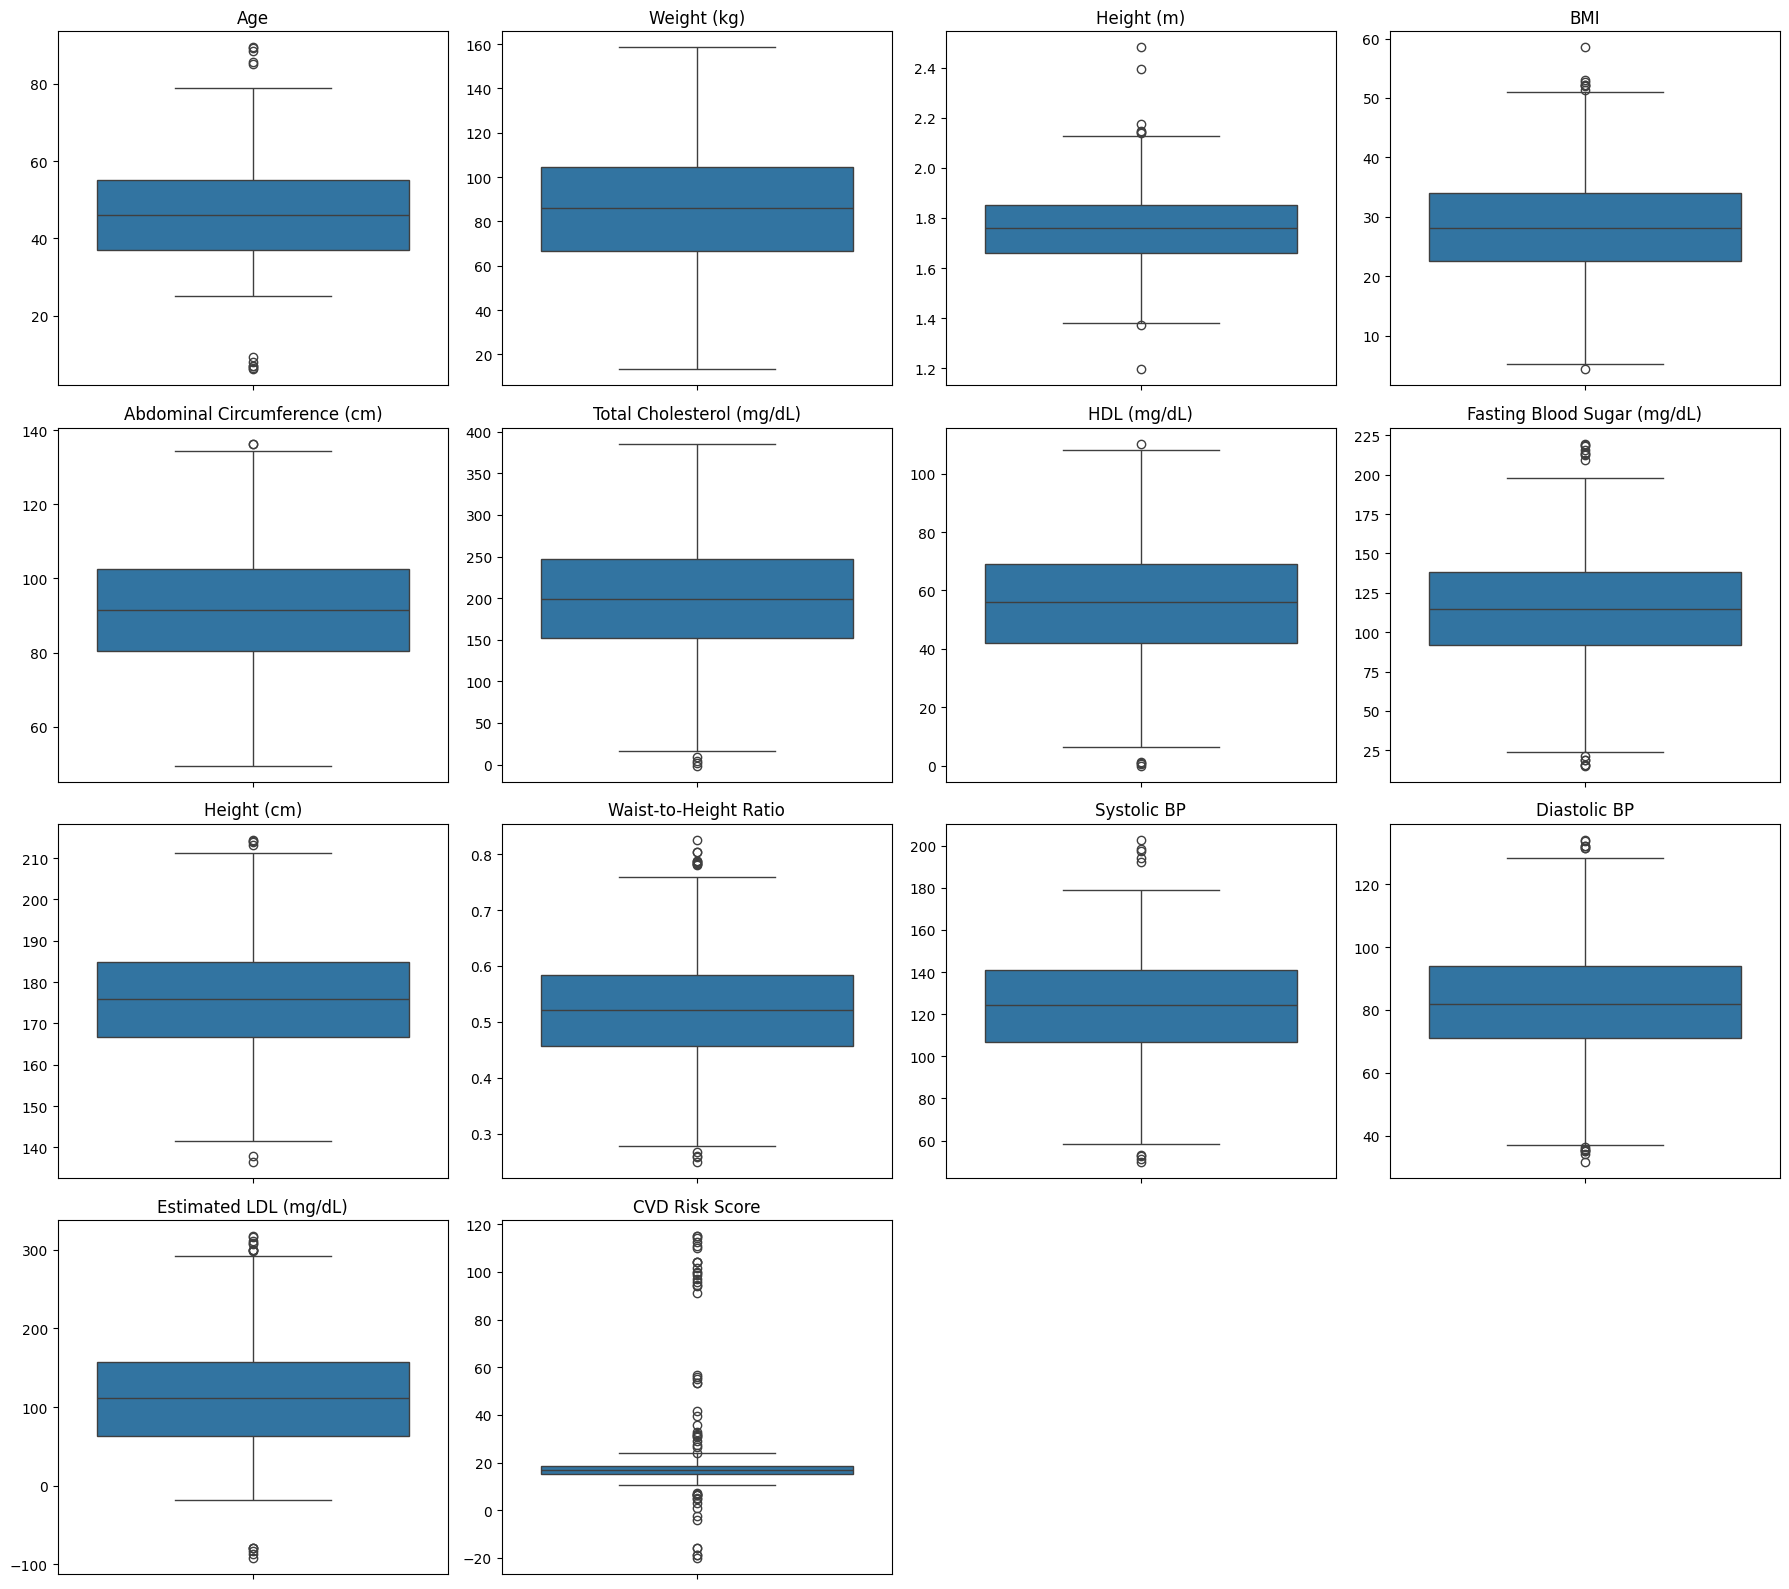

In [262]:
# Seleccionar columnas numéricas
num_cols = datos.select_dtypes(include="number").columns

# Definir tamaño del grid
n_cols = 4  # número de gráficos por fila
n_rows = math.ceil(len(num_cols) / n_cols)

# Crear figura
plt.figure(figsize=(18, 4 * n_rows))

# Crear un boxplot por variable
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=datos[col])
    plt.title(col)
    plt.ylabel("")
    
plt.tight_layout()
plt.show()

#### Detección exhaustiva + corrección

##### Asegurar tipos numéricos

In [263]:
# Columnas numéricas esperadas
num_cols = [
    "Age","Weight (kg)","Height (m)","BMI","Abdominal Circumference (cm)",
    "Total Cholesterol (mg/dL)","HDL (mg/dL)","Fasting Blood Sugar (mg/dL)",
    "Height (cm)","Waist-to-Height Ratio","Systolic BP","Diastolic BP",
    "Estimated LDL (mg/dL)","CVD Risk Score"
]

for c in num_cols:
    if c in datos.columns:
        datos[c] = pd.to_numeric(datos[c], errors="coerce")

##### Normalizar strings

In [264]:
str_cols = [
    "Patient ID","Sex","Smoking Status","Diabetes Status","Physical Activity Level",
    "Family History of CVD","Blood Pressure (mmHg)","Blood Pressure Category",
    "CVD Risk Level"
]
for c in str_cols:
    if c in datos.columns:
        datos[c] = datos[c].astype("string").str.strip()

##### Reglas de rango y marcar como inválido

In [265]:
# Reglas de rango (min, max)
ranges = {
    "Age": (0, 120),
    "Weight (kg)": (0, 300),
    "Height (m)": (1.20, 2.30),
    "Height (cm)": (120, 230),
    "BMI": (10, 80),
    "Abdominal Circumference (cm)": (40, 200),
    "Waist-to-Height Ratio": (0.20, 0.90),
    "Systolic BP": (70, 250),
    "Diastolic BP": (40, 150),
    "Total Cholesterol (mg/dL)": (70, 400),
    "HDL (mg/dL)": (10, 150),
    "Fasting Blood Sugar (mg/dL)": (40, 400),
    "Estimated LDL (mg/dL)": (0, 300),
    "CVD Risk Score": (0, 100)  # Más de 100 no tiene sentido
}

invalid_counts = {}

for col, (lo, hi) in ranges.items():
    if col not in datos.columns:
        continue
    m = datos[col].notna() & ((datos[col] < lo) | (datos[col] > hi))
    invalid_counts[col] = int(m.sum())
    # Marca inválidos como NaN (para luego imputar)
    datos.loc[m, col] = np.nan

invalid_counts

{'Age': 0,
 'Weight (kg)': 0,
 'Height (m)': 3,
 'Height (cm)': 0,
 'BMI': 4,
 'Abdominal Circumference (cm)': 0,
 'Waist-to-Height Ratio': 0,
 'Systolic BP': 5,
 'Diastolic BP': 9,
 'Total Cholesterol (mg/dL)': 7,
 'HDL (mg/dL)': 7,
 'Fasting Blood Sugar (mg/dL)': 7,
 'Estimated LDL (mg/dL)': 23,
 'CVD Risk Score': 17}

##### Después de marcar como inválidos volvemos a completitud

In [266]:
cols_mediana = [
    "Age",
    "Total Cholesterol (mg/dL)",
    "HDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)",
    "Estimated LDL (mg/dL)",
    "CVD Risk Score"
]

for col in cols_mediana:
    if col in datos.columns:
        datos[col] = datos[col].fillna(datos[col].median())
        
cat_cols_moda = ["Sex","Smoking Status","Diabetes Status","Family History of CVD","Physical Activity Level","CVD Risk Level"]

for col in cat_cols_moda:
    if col in datos.columns and datos[col].isna().any():
        datos[col] = datos[col].fillna(datos[col].mode(dropna=True).iloc[0])

In [267]:

# 1. Completar Height (m) desde Height (cm)

cond_h = datos["Height (m)"].isna() & datos["Height (cm)"].notna()

datos.loc[cond_h, "Height (m)"] = (
    datos.loc[cond_h, "Height (cm)"] / 100
)


# 2. Completar BMI usando fórmula

cond_bmi = (
    datos["BMI"].isna() &
    datos["Weight (kg)"].notna() &
    datos["Height (m)"].notna()
)

datos.loc[cond_bmi, "BMI"] = (
    datos.loc[cond_bmi, "Weight (kg)"] /
    (datos.loc[cond_bmi, "Height (m)"]**2)
)


# 3. Recuperar presión arterial desde string

bp = datos["Blood Pressure (mmHg)"].str.split("/", expand=True)

# Systolic
cond_sys = datos["Systolic BP"].isna() & bp[0].notna()
datos.loc[cond_sys, "Systolic BP"] = bp.loc[cond_sys, 0].astype(float)

# Diastolic
cond_dia = datos["Diastolic BP"].isna() & bp[1].notna()
datos.loc[cond_dia, "Diastolic BP"] = bp.loc[cond_dia, 1].astype(float)


# 4. Imputación final con mediana (solo si aún queda algo)

cols_final = ["Height (m)", "BMI", "Systolic BP", "Diastolic BP"]

for col in cols_final:
    datos[col] = datos[col].fillna(datos[col].median())


# 5. Verificación final

print("Faltantes restantes:")
print(datos[cols_final].isna().sum())

Faltantes restantes:
Height (m)      0
BMI             0
Systolic BP     0
Diastolic BP    0
dtype: int64


### Consistencia

#### Heatmap de correlación

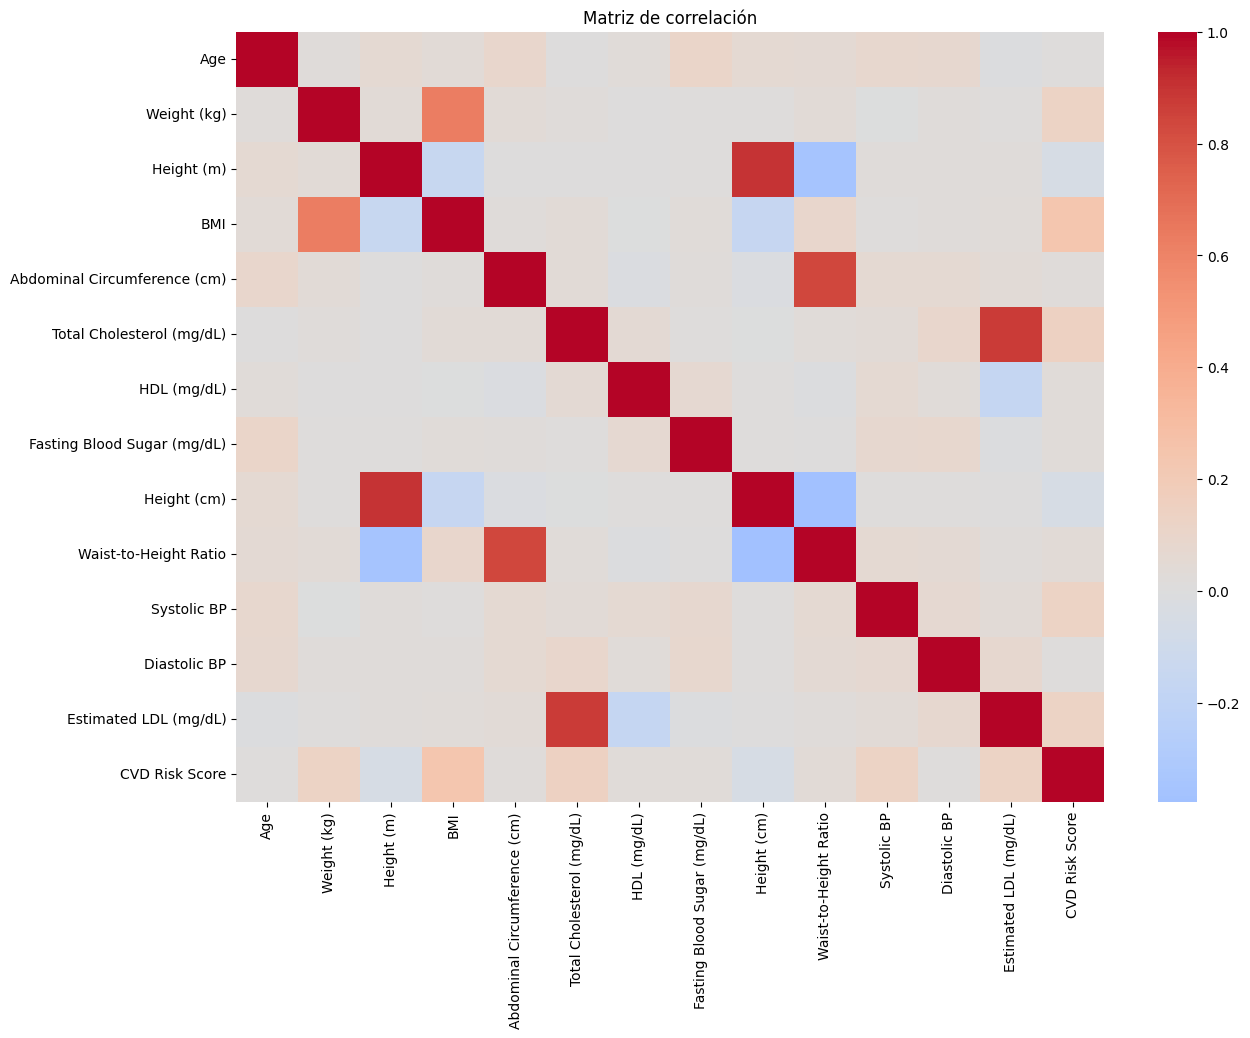

In [268]:
plt.figure(figsize=(14,10))
sns.heatmap(datos.corr(numeric_only=True),
            cmap="coolwarm",
            center=0,
            annot=False)

plt.title("Matriz de correlación")
plt.show()

#### Revisamos consistencia entre Height (m) y (cm)

In [269]:
((datos["Height (m)"]*100 - datos["Height (cm)"]).abs() > 1).sum()

np.int64(34)

Corregimos

In [270]:
datos["Height (cm)"] = datos["Height (m)"] * 100

#### Revisamos consistencia entre BMI, Weight (kg) y Height (m)

In [271]:
bmi_check = datos["Weight (kg)"]/(datos["Height (m)"]**2)

(abs(datos["BMI"] - bmi_check) > 0.1).sum()

np.int64(445)

Recalculamos el BMI

In [272]:
datos["BMI"] = datos["Weight (kg)"] / (datos["Height (m)"]**2)

Eliminamos los registros con BMI fuera del rango válido

In [273]:
# eliminar registros con BMI fuera de rango válido
datos = datos[(datos["BMI"] >= 10) & (datos["BMI"] <= 80)]

print("Nuevo tamaño del dataset:", datos.shape)

Nuevo tamaño del dataset: (1363, 24)


#### Revisamos consistencia entre Systolic BP y Diastolic BP

In [274]:
# 1. Detectar inconsistencias médicas
mask_bp = datos["Systolic BP"] < datos["Diastolic BP"]
print("Inconsistencias iniciales:", mask_bp.sum())

# 2. Extraer valores desde la fuente original
bp = datos["Blood Pressure (mmHg)"].astype("string").str.split("/", expand=True)

bp_sys = pd.to_numeric(bp[0], errors="coerce")
bp_dia = pd.to_numeric(bp[1], errors="coerce")

# 3. Reconstruir SOLO registros inconsistentes
datos.loc[mask_bp, "Systolic BP"] = bp_sys.loc[mask_bp]
datos.loc[mask_bp, "Diastolic BP"] = bp_dia.loc[mask_bp]

# 4. Revisar nuevamente
mask_bp = datos["Systolic BP"] < datos["Diastolic BP"]

# 5. Si aún quedan inconsistencias → invalidar e imputar
datos.loc[mask_bp, ["Systolic BP", "Diastolic BP"]] = np.nan

datos["Systolic BP"] = datos["Systolic BP"].fillna(datos["Systolic BP"].median())
datos["Diastolic BP"] = datos["Diastolic BP"].fillna(datos["Diastolic BP"].median())

# 6. Validación final
print("Inconsistencias finales:",
      (datos["Systolic BP"] < datos["Diastolic BP"]).sum())

Inconsistencias iniciales: 57
Inconsistencias finales: 0


#### Revalidación

In [275]:
print("Height inconsistentes:",
      ((datos["Height (m)"]*100 - datos["Height (cm)"]).abs() > 1).sum())

print("BMI inconsistentes:",
      (abs(datos["BMI"] -
           datos["Weight (kg)"]/(datos["Height (m)"]**2)) > 0.1).sum())

print("Presión arterial inconsistente:",
      (datos["Systolic BP"] < datos["Diastolic BP"]).sum())

Height inconsistentes: 0
BMI inconsistentes: 0
Presión arterial inconsistente: 0


### Verificación final

In [276]:
print("========== AUDITORÍA FINAL DE CALIDAD ==========\n")


# 1. COMPLETITUD

faltantes_totales = datos.isna().sum().sum()

print("COMPLETITUD")
print("Faltantes totales:", faltantes_totales)
print("Estado:", "✅ OK" if faltantes_totales == 0 else "❌ Hay faltantes")
print()


# 2. UNICIDAD

dup_exactos = datos.duplicated().sum()

dup_logicos = datos.duplicated(
    subset=["Patient ID", "Date of Service"]
).sum()

print("UNICIDAD")
print("Duplicados exactos:", dup_exactos)
print("Duplicados (Patient ID + Date):", dup_logicos)
print("Estado:", "✅ OK" if dup_exactos == 0 and dup_logicos == 0 else "❌ Hay duplicados")
print()


# 3. VALIDEZ (NUEVOS RANGOS)

ranges = {
    "Age": (0, 120),
    "Weight (kg)": (0, 300),
    "Height (m)": (1.20, 2.30),
    "Height (cm)": (120, 230),
    "BMI": (10, 80),
    "Abdominal Circumference (cm)": (40, 200),
    "Waist-to-Height Ratio": (0.20, 0.90),
    "Systolic BP": (70, 250),
    "Diastolic BP": (40, 150),
    "Total Cholesterol (mg/dL)": (70, 400),
    "HDL (mg/dL)": (10, 150),
    "Fasting Blood Sugar (mg/dL)": (40, 400),
    "Estimated LDL (mg/dL)": (0, 300),
    "CVD Risk Score": (0, np.inf)
}

invalid_validez = {}

for col, (lo, hi) in ranges.items():
    if col in datos.columns:
        invalid_validez[col] = int(
            ((datos[col] < lo) | (datos[col] > hi)).sum()
        )

total_invalid = sum(invalid_validez.values())

print("VALIDEZ")
print("Valores fuera de rango:", total_invalid)
print("Detalle:", invalid_validez)
print("Estado:", "✅ OK" if total_invalid == 0 else "❌ Hay valores inválidos")
print()


# 4. CONSISTENCIA

height_incons = ((datos["Height (m)"]*100 - datos["Height (cm)"]).abs() > 1).sum()

bmi_calc = datos["Weight (kg)"]/(datos["Height (m)"]**2)
bmi_incons = (abs(datos["BMI"] - bmi_calc) > 0.1).sum()

bp_incons = (datos["Systolic BP"] < datos["Diastolic BP"]).sum()

print("CONSISTENCIA")
print("Height inconsistentes:", int(height_incons))
print("BMI inconsistentes:", int(bmi_incons))
print("BP inconsistentes:", int(bp_incons))

consistencia_ok = (height_incons == 0 and bmi_incons == 0 and bp_incons == 0)

print("Estado:", "✅ OK" if consistencia_ok else "❌ Hay inconsistencias")
print()


# RESULTADO FINAL

if (
    faltantes_totales == 0
    and dup_exactos == 0
    and dup_logicos == 0
    and total_invalid == 0
    and consistencia_ok
):
    print("🎉 DATASET COMPLETAMENTE LIMPIO Y VALIDADO")
else:
    print("⚠️ Aún existen problemas de calidad de datos")

========== AUDITORÍA FINAL DE CALIDAD ==========

COMPLETITUD
Faltantes totales: 0
Estado: ✅ OK

UNICIDAD
Duplicados exactos: 0
Duplicados (Patient ID + Date): 0
Estado: ✅ OK

VALIDEZ
Valores fuera de rango: 0
Detalle: {'Age': 0, 'Weight (kg)': 0, 'Height (m)': 0, 'Height (cm)': 0, 'BMI': 0, 'Abdominal Circumference (cm)': 0, 'Waist-to-Height Ratio': 0, 'Systolic BP': 0, 'Diastolic BP': 0, 'Total Cholesterol (mg/dL)': 0, 'HDL (mg/dL)': 0, 'Fasting Blood Sugar (mg/dL)': 0, 'Estimated LDL (mg/dL)': 0, 'CVD Risk Score': 0}
Estado: ✅ OK

CONSISTENCIA
Height inconsistentes: 0
BMI inconsistentes: 0
BP inconsistentes: 0
Estado: ✅ OK

🎉 DATASET COMPLETAMENTE LIMPIO Y VALIDADO


## 2. Transformación de los datos

Ya se hizo la limpieza necesaria en términos de completitud, unicidad validez y consistencia. Sin embargo, aún es necesario transformar los datos para que se puedan usar en el modelo de regresión lineal.

Primero, se va a determinar la codificación de variables categóricas, pues estas constituyen una parte importante de los datos. Se pueden identificar los siguientes datos categóricos:
- Sex
- Smoking Status
- Diabetes Status
- Physical Activity Level
- Family of History of CVD
- Blood Pressure Category
- CVD Risk Level

In [277]:
datos_transformados = datos.copy()

Se va a empezar con la transformación de las variables categóricas que tienen valores booleanos. Estas son Sex, Smoking Status, Diabetes Status y Family History of CVD. Vale la pena mencionar que a pesa de que en el diccionario se muestra que Sex es un String, pero como tiene solo 2 posibles valores, se puede considerar como booleana. 

A estas variables simplemente se les asignara un 0 o un 1 dependiendo de su valor.

Para Smoking Status, Diabetes Status y Family History of CVD:

Y = 0
N = 1

Para Sex:

M = 0
F = 1

In [278]:
print(datos_transformados["Sex"].value_counts())
print()
print(datos_transformados["Smoking Status"].value_counts())
print()
print(datos_transformados["Diabetes Status"].value_counts())
print()
print(datos_transformados["Family History of CVD"].value_counts())

Sex
F    691
M    672
Name: count, dtype: Int64

Smoking Status
Y    705
N    658
Name: count, dtype: Int64

Diabetes Status
Y    694
N    669
Name: count, dtype: Int64

Family History of CVD
N    695
Y    668
Name: count, dtype: Int64


In [279]:
# Encoders para las variables con el orden deseado
encoder_sex = OrdinalEncoder(categories=[['M', 'F']])
encoder_otros = OrdinalEncoder(categories=[['N', 'Y']])

In [280]:
datos_transformados['Sex'] = encoder_sex.fit_transform(datos_transformados[['Sex']]).astype(int)
datos_transformados['Smoking Status'] = encoder_otros.fit_transform(datos_transformados[['Smoking Status']]).astype(int)
datos_transformados['Diabetes Status'] = encoder_otros.fit_transform(datos_transformados[['Diabetes Status']]).astype(int)
datos_transformados['Family History of CVD'] = encoder_otros.fit_transform(datos_transformados[['Family History of CVD']]).astype(int)

In [281]:
print(datos_transformados["Sex"].value_counts())
print()
print(datos_transformados["Smoking Status"].value_counts())
print()
print(datos_transformados["Diabetes Status"].value_counts())
print()
print(datos_transformados["Family History of CVD"].value_counts())

Sex
1    691
0    672
Name: count, dtype: int64

Smoking Status
1    705
0    658
Name: count, dtype: int64

Diabetes Status
1    694
0    669
Name: count, dtype: int64

Family History of CVD
0    695
1    668
Name: count, dtype: int64


Las otras variables categóricas no son binarias:

In [282]:
print(datos_transformados["Physical Activity Level"].value_counts())
print()
print(datos_transformados["Blood Pressure Category"].value_counts())
print()
print(datos_transformados["CVD Risk Level"].value_counts())

Physical Activity Level
High        465
Moderate    457
Low         441
Name: count, dtype: Int64

Blood Pressure Category
Hypertension Stage 2    561
Hypertension Stage 1    448
Normal                  264
Elevated                 90
Name: count, dtype: Int64

CVD Risk Level
HIGH            650
INTERMEDIARY    515
LOW             198
Name: count, dtype: Int64


Existe un orden jerárquico natural dentro de estas variables. Por esto, se les pueden asignar valores numéricos a estas categorías ya que siguen un orden lógico.

In [283]:
# Encoders para las variables con el orden deseado
encoder_actividad = OrdinalEncoder(categories=[['Low', 'Moderate', 'High']])
encoder_presion = OrdinalEncoder(categories=[['Normal', 'Elevated', 'Hypertension Stage 1', 'Hypertension Stage 2']])
encoder_nivel = OrdinalEncoder(categories=[['LOW', 'INTERMEDIARY', 'HIGH']])

In [284]:
datos_transformados['Physical Activity Level'] = encoder_actividad.fit_transform(datos_transformados[['Physical Activity Level']]).astype(int)
datos_transformados['Blood Pressure Category'] = encoder_presion.fit_transform(datos_transformados[['Blood Pressure Category']]).astype(int)
datos_transformados['CVD Risk Level'] = encoder_nivel.fit_transform(datos_transformados[['CVD Risk Level']]).astype(int)

In [285]:
print(datos_transformados["Physical Activity Level"].value_counts())
print()
print(datos_transformados["Blood Pressure Category"].value_counts())
print()
print(datos_transformados["CVD Risk Level"].value_counts())

Physical Activity Level
2    465
1    457
0    441
Name: count, dtype: int64

Blood Pressure Category
3    561
2    448
0    264
1     90
Name: count, dtype: int64

CVD Risk Level
2    650
1    515
0    198
Name: count, dtype: int64


Ahora que los datos categóricos pueden ser analizados numéricamente, se pueden llevar las variables que se van a usar para el modelo a una escala común. Como las variables varían mucho y tienen rangos muy diferentes, se decidió que estas se van a estandarizar. 

No todas las variables deben ser estandarizadas. Unas variables no tienen sentido si se estandarizan. Por ejemplo, la fecha. Otras variables no tienen sentido usar. Por ejemplo, si se usa Waist-to-Height Ratio, no es necesaro usar Abdominal Circumference o Altura. Otro ejemplo es CVD Risk Level, que este viede de la variable objetivo CVD Risk Score.

A continuación se va a crear un dataframe con solo las variables que van a ser utilizadas para el modelo.

In [286]:
datos_para_modelo = datos_transformados.copy()

columnas_eliminar = [
    "Patient ID",
    "Date of Service",
    "CVD Risk Level",
    "Blood Pressure (mmHg)",
    "Height (cm)",
    "Weight (kg)",
    "Height (m)",
    "Abdominal Circumference (cm)",
    "Blood Pressure Category"
]

datos_para_modelo = datos_para_modelo.drop(columns=columnas_eliminar)

In [287]:
datos_para_modelo.info()

<class 'pandas.DataFrame'>
Index: 1363 entries, 0 to 1638
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Sex                          1363 non-null   int64  
 1   Age                          1363 non-null   float64
 2   BMI                          1363 non-null   float64
 3   Total Cholesterol (mg/dL)    1363 non-null   float64
 4   HDL (mg/dL)                  1363 non-null   float64
 5   Fasting Blood Sugar (mg/dL)  1363 non-null   float64
 6   Smoking Status               1363 non-null   int64  
 7   Diabetes Status              1363 non-null   int64  
 8   Physical Activity Level      1363 non-null   int64  
 9   Family History of CVD        1363 non-null   int64  
 10  Waist-to-Height Ratio        1363 non-null   float64
 11  Systolic BP                  1363 non-null   float64
 12  Diastolic BP                 1363 non-null   float64
 13  Estimated LDL (mg/dL)        1363 

Para escalar, es necesario definir X y Y del modelo. Además, solo se deben estandarizar las variables numéricas continuas. 

In [288]:
from sklearn.model_selection import train_test_split

target = "CVD Risk Score"

# Separar variables predictoras (X) y variable objetivo (y)
X = datos_para_modelo.drop(columns=[target])
y = datos_para_modelo[target]

# División 75% entrenamiento / 25% prueba (similar al lab de Regresión Lineal)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1
)


In [289]:
columnas_continuas = [
    "Age",
    "BMI",
    "Waist-to-Height Ratio",
    "Total Cholesterol (mg/dL)",
    "HDL (mg/dL)",
    "Estimated LDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)",
    "Systolic BP",
    "Diastolic BP"
]

scaler = StandardScaler()

# Ajustar SOLO con entrenamiento y transformar ambos conjuntos (train/test)
X_train[columnas_continuas] = scaler.fit_transform(X_train[columnas_continuas])
X_test[columnas_continuas] = scaler.transform(X_test[columnas_continuas])


In [290]:
X_train

,Sex,Age,BMI,Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Smoking Status,Diabetes Status,Physical Activity Level,Family History of CVD,Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL)
836,1,0.473066,0.727970,-0.446051,-1.145902,1.429979,1,1,2,1,1.310672,0.756189,-1.064629,-0.116202
265,0,0.160217,1.353131,-0.786943,0.948599,-0.246988,0,1,1,0,1.275836,-0.036756,-0.059500,-1.049821
77,0,-0.074420,-1.077888,1.473708,0.123493,-0.148343,0,0,2,0,-1.731715,-1.482715,0.299474,1.445816
240,0,0.394853,0.375420,1.563416,1.012069,1.068280,0,1,0,1,-0.767905,-1.389427,0.730244,1.284228
1163,0,-0.465481,2.584013,0.163966,0.821660,-1.101913,0,1,1,1,-0.605335,1.595778,0.730244,-0.062339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
803,1,-1.482240,-0.096224,1.760775,1.583297,0.969635,0,1,2,0,-1.278840,1.968928,0.945628,1.320136
1055,1,0.473066,-1.114774,0.002491,1.075539,0.377764,0,1,2,0,-0.675008,-0.269975,-1.064629,-0.295744
1289,1,1.333400,-1.158349,0.253674,0.123493,-1.101913,1,1,1,1,1.124878,2.248791,-0.921039,0.224929
247,1,-0.465481,0.180789,1.025166,1.075539,0.542173,1,1,0,0,-1.418186,0.989408,-1.064629,0.727647


In [291]:
y_train

836     19.715
265     17.420
77      14.270
240     18.123
1163    18.993
         ...  
803     22.642
1055    15.870
1289    16.951
247     20.440
1246    15.260
Name: CVD Risk Score, Length: 1022, dtype: float64

## 3. Construcción del pipeline de preparación de datos

En esta sección se encapsula **todo el proceso de limpieza + transformación + escalado** en un **pipeline reutilizable**.
No se cambia la lógica del proceso. Los pasos aplicados dentro del pipeline replican exactamente las mismas operaciones realizadas previamente sobre los datos.


In [292]:
def limpiar_datos_pacientes(df: pd.DataFrame) -> pd.DataFrame:
    """Aplica EXACTAMENTE las mismas reglas de limpieza definidas en el notebook,
    pero encapsuladas en una sola función para reutilizarse dentro de un pipeline.
    """
    datos = df.copy()


    # COMPLETITUD: imputaciones determinísticas

    # BMI, Height (m) y Weight (kg)
    condicion = (
        datos["Height (m)"].isna() &
        datos["Weight (kg)"].notna() &
        datos["BMI"].notna()
    )
    datos.loc[condicion, "Height (m)"] = np.sqrt(
        datos.loc[condicion, "Weight (kg)"] /
        datos.loc[condicion, "BMI"]
    )

    condicion_weight = (
        datos["Weight (kg)"].isna() &
        datos["Height (m)"].notna() &
        datos["BMI"].notna()
    )
    datos.loc[condicion_weight, "Weight (kg)"] = (
        datos.loc[condicion_weight, "BMI"] *
        datos.loc[condicion_weight, "Height (m)"]**2
    )

    condicion_bmi = (
        datos["BMI"].isna() &
        datos["Weight (kg)"].notna() &
        datos["Height (m)"].notna()
    )
    datos.loc[condicion_bmi, "BMI"] = (
        datos.loc[condicion_bmi, "Weight (kg)"] /
        (datos.loc[condicion_bmi, "Height (m)"]**2)
    )

    # Borrar filas con faltantes (tras las correcciones)
    datos = datos.dropna(subset=["Weight (kg)", "Height (m)", "BMI"])

    # Height (m) <-> Height (cm)
    cond_cm = datos["Height (cm)"].isna() & datos["Height (m)"].notna()
    datos.loc[cond_cm, "Height (cm)"] = (
        datos.loc[cond_cm, "Height (m)"] * 100
    )

    cond_m = datos["Height (m)"].isna() & datos["Height (cm)"].notna()
    datos.loc[cond_m, "Height (m)"] = (
        datos.loc[cond_m, "Height (cm)"] / 100
    )

    # Waist-to-Height Ratio
    cond_whr = (
        datos["Waist-to-Height Ratio"].isna() &
        datos["Abdominal Circumference (cm)"].notna() &
        datos["Height (cm)"].notna()
    )
    datos.loc[cond_whr, "Waist-to-Height Ratio"] = (
        datos.loc[cond_whr, "Abdominal Circumference (cm)"] /
        datos.loc[cond_whr, "Height (cm)"]
    )

    # Abdominal Circumference (cm)
    cond_abd = (
        datos["Waist-to-Height Ratio"].notna() &
        datos["Abdominal Circumference (cm)"].isna() &
        datos["Height (cm)"].notna()
    )
    datos.loc[cond_abd, "Abdominal Circumference (cm)"] = (
        datos.loc[cond_abd, "Waist-to-Height Ratio"] *
        datos.loc[cond_abd, "Height (cm)"]
    )

    # Borrar filas con faltantes restantes
    datos = datos.dropna(subset=["Waist-to-Height Ratio", "Abdominal Circumference (cm)", "Height (cm)"])

    # Blood Pressure (mmHg) -> Systolic / Diastolic (si aplica)
    bp_split = datos["Blood Pressure (mmHg)"].str.split("/", expand=True)

    cond_sys = (
        datos["Systolic BP"].isna() &
        datos["Blood Pressure (mmHg)"].notna()
    )
    datos.loc[cond_sys, "Systolic BP"] = bp_split.loc[cond_sys, 0].astype(float)

    cond_dia = (
        datos["Diastolic BP"].isna() &
        datos["Blood Pressure (mmHg)"].notna()
    )
    datos.loc[cond_dia, "Diastolic BP"] = bp_split.loc[cond_dia, 1].astype(float)


    # IMPUTACIÓN ESTADÍSTICA (mediana) - primera pasada

    cols_mediana = [
        "Age",
        "Total Cholesterol (mg/dL)",
        "HDL (mg/dL)",
        "Fasting Blood Sugar (mg/dL)",
        "Estimated LDL (mg/dL)",
        "CVD Risk Score"
    ]
    for col in cols_mediana:
        datos[col] = datos[col].fillna(datos[col].median())


    # UNICIDAD: duplicados exactos y por clave

    datos = datos.drop_duplicates()

    datos["Date of Service"] = pd.to_datetime(
        datos["Date of Service"],
        format="mixed",   # permite múltiples formatos
        dayfirst=True,    # interpreta correctamente DD/MM/YYYY
        errors="coerce"   # valores inválidos → NaT
    )

    datos = datos.drop_duplicates(
        subset=["Patient ID", "Date of Service"]
    )


    # VALIDEZ: asegurar tipos + normalizar strings + rangos
 
    # 1) Tipos numéricos
    num_cols = [
        "Age","Weight (kg)","Height (m)","BMI","Abdominal Circumference (cm)",
        "Total Cholesterol (mg/dL)","HDL (mg/dL)","Fasting Blood Sugar (mg/dL)",
        "Height (cm)","Waist-to-Height Ratio","Systolic BP","Diastolic BP",
        "Estimated LDL (mg/dL)","CVD Risk Score"
    ]
    for c in num_cols:
        if c in datos.columns:
            datos[c] = pd.to_numeric(datos[c], errors="coerce")

    # 2) Normalizar strings
    str_cols = [
        "Patient ID","Sex","Smoking Status","Diabetes Status","Physical Activity Level",
        "Family History of CVD","Blood Pressure (mmHg)","Blood Pressure Category",
        "CVD Risk Level"
    ]
    for c in str_cols:
        if c in datos.columns:
            datos[c] = datos[c].astype("string").str.strip()

    # 3) Reglas de rango y marcar como inválido (NaN)
    ranges = {
        "Age": (0, 120),
        "Weight (kg)": (0, 300),
        "Height (m)": (1.20, 2.30),
        "Height (cm)": (120, 230),
        "BMI": (10, 80),
        "Abdominal Circumference (cm)": (40, 200),
        "Waist-to-Height Ratio": (0.20, 0.90),
        "Systolic BP": (70, 250),
        "Diastolic BP": (40, 150),
        "Total Cholesterol (mg/dL)": (70, 400),
        "HDL (mg/dL)": (10, 150),
        "Fasting Blood Sugar (mg/dL)": (40, 400),
        "Estimated LDL (mg/dL)": (0, 300),
        "CVD Risk Score": (0, 100)  # Más de 100 no tiene sentido
    }

    for col, (lo, hi) in ranges.items():
        if col not in datos.columns:
            continue
        m = datos[col].notna() & ((datos[col] < lo) | (datos[col] > hi))
        # Marca inválidos como NaN (para luego imputar)
        datos.loc[m, col] = np.nan


    # VOLVER A COMPLETITUD DESPUÉS DE INVALIDAR

    cols_mediana = [
        "Age",
        "Total Cholesterol (mg/dL)",
        "HDL (mg/dL)",
        "Fasting Blood Sugar (mg/dL)",
        "Estimated LDL (mg/dL)",
        "CVD Risk Score"
    ]
    for col in cols_mediana:
        datos[col] = datos[col].fillna(datos[col].median())

    cat_cols_moda = ["Sex","Smoking Status","Diabetes Status","Family History of CVD","Physical Activity Level","CVD Risk Level"]
    for col in cat_cols_moda:
        if col in datos.columns and datos[col].isna().any():
            datos[col] = datos[col].fillna(datos[col].mode(dropna=True).iloc[0])


    # RECUPERACIONES + IMPUTACIÓN FINAL (tal cual el notebook)

    # 1. Completar Height (m) desde Height (cm)
    cond_h = datos["Height (m)"].isna() & datos["Height (cm)"].notna()
    datos.loc[cond_h, "Height (m)"] = (
        datos.loc[cond_h, "Height (cm)"] / 100
    )

    # 2. Completar BMI usando fórmula
    cond_bmi = (
        datos["BMI"].isna() &
        datos["Weight (kg)"].notna() &
        datos["Height (m)"].notna()
    )
    datos.loc[cond_bmi, "BMI"] = (
        datos.loc[cond_bmi, "Weight (kg)"] /
        (datos.loc[cond_bmi, "Height (m)"]**2)
    )

    # 3. Recuperar presión arterial desde string
    bp = datos["Blood Pressure (mmHg)"].str.split("/", expand=True)

    cond_sys = datos["Systolic BP"].isna() & bp[0].notna()
    datos.loc[cond_sys, "Systolic BP"] = bp.loc[cond_sys, 0].astype(float)

    cond_dia = datos["Diastolic BP"].isna() & bp[1].notna()
    datos.loc[cond_dia, "Diastolic BP"] = bp.loc[cond_dia, 1].astype(float)

    # 4. Imputación final con mediana (solo si aún queda algo)
    cols_final = ["Height (m)", "BMI", "Systolic BP", "Diastolic BP"]
    for col in cols_final:
        datos[col] = datos[col].fillna(datos[col].median())


    # CONSISTENCIA: correcciones finales tal cual el notebook

    # Height (cm) coherente con Height (m)
    datos["Height (cm)"] = datos["Height (m)"] * 100

    # Recalcular BMI y filtrar fuera de rango válido
    datos["BMI"] = datos["Weight (kg)"] / (datos["Height (m)"]**2)
    datos = datos[(datos["BMI"] >= 10) & (datos["BMI"] <= 80)]

    # Systolic BP vs Diastolic BP
    mask_bp = datos["Systolic BP"] < datos["Diastolic BP"]

    bp = datos["Blood Pressure (mmHg)"].astype("string").str.split("/", expand=True)
    bp_sys = pd.to_numeric(bp[0], errors="coerce")
    bp_dia = pd.to_numeric(bp[1], errors="coerce")

    datos.loc[mask_bp, "Systolic BP"] = bp_sys.loc[mask_bp]
    datos.loc[mask_bp, "Diastolic BP"] = bp_dia.loc[mask_bp]

    mask_bp = datos["Systolic BP"] < datos["Diastolic BP"]
    datos.loc[mask_bp, ["Systolic BP", "Diastolic BP"]] = np.nan

    datos["Systolic BP"] = datos["Systolic BP"].fillna(datos["Systolic BP"].median())
    datos["Diastolic BP"] = datos["Diastolic BP"].fillna(datos["Diastolic BP"].median())

    return datos


In [293]:
def transformar_datos_pacientes(df: pd.DataFrame) -> pd.DataFrame:
    """Aplica EXACTAMENTE las mismas transformaciones del notebook:
    - Ordinal encoding con el orden definido
    - Eliminación de columnas no usadas para el modelo
    Retorna un DataFrame listo para separar en X/y (incluye el target).
    """
    datos_transformados = df.copy()

    # Variables categóricas binarias
    encoder_sex = OrdinalEncoder(categories=[['M', 'F']])
    encoder_otros = OrdinalEncoder(categories=[['N', 'Y']])

    datos_transformados['Sex'] = encoder_sex.fit_transform(datos_transformados[['Sex']]).astype(int)
    datos_transformados['Smoking Status'] = encoder_otros.fit_transform(datos_transformados[['Smoking Status']]).astype(int)
    datos_transformados['Diabetes Status'] = encoder_otros.fit_transform(datos_transformados[['Diabetes Status']]).astype(int)
    datos_transformados['Family History of CVD'] = encoder_otros.fit_transform(datos_transformados[['Family History of CVD']]).astype(int)

    # Variables categóricas ordinales
    encoder_actividad = OrdinalEncoder(categories=[['Low', 'Moderate', 'High']])
    encoder_presion = OrdinalEncoder(categories=[['Normal', 'Elevated', 'Hypertension Stage 1', 'Hypertension Stage 2']])
    encoder_nivel = OrdinalEncoder(categories=[['LOW', 'INTERMEDIARY', 'HIGH']])

    datos_transformados['Physical Activity Level'] = encoder_actividad.fit_transform(datos_transformados[['Physical Activity Level']]).astype(int)
    datos_transformados['Blood Pressure Category'] = encoder_presion.fit_transform(datos_transformados[['Blood Pressure Category']]).astype(int)
    datos_transformados['CVD Risk Level'] = encoder_nivel.fit_transform(datos_transformados[['CVD Risk Level']]).astype(int)

    # Eliminar columnas no usadas en el modelo
    datos_para_modelo = datos_transformados.copy()

    columnas_eliminar = [
        "Patient ID",
        "Date of Service",
        "CVD Risk Level",
        "Blood Pressure (mmHg)",
        "Height (cm)",
        "Weight (kg)",
        "Height (m)",
        "Abdominal Circumference (cm)",
        "Blood Pressure Category"
    ]

    datos_para_modelo = datos_para_modelo.drop(columns=columnas_eliminar)

    return datos_para_modelo


In [294]:
class EscaladorColumnas(BaseEstimator, TransformerMixin):
    """Estandariza únicamente las columnas continuas (mismo criterio del notebook),
    preservando nombres y orden de columnas.
    """
    def __init__(self, columnas_continuas):
        self.columnas_continuas = list(columnas_continuas)

    def fit(self, X, y=None):
        # atributo con "_" para que sklearn lo reconozca como "fitted"
        self.scaler_ = StandardScaler()
        self.scaler_.fit(X[self.columnas_continuas])
        return self

    def transform(self, X):
        X_ = X.copy()
        X_[self.columnas_continuas] = self.scaler_.transform(X_[self.columnas_continuas])
        return X_

# Columnas continuas (exactamente como en el notebook)
columnas_continuas = [
    "Age",
    "BMI",
    "Waist-to-Height Ratio",
    "Total Cholesterol (mg/dL)",
    "HDL (mg/dL)",
    "Estimated LDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)",
    "Systolic BP",
    "Diastolic BP"
]

pipeline_preparacion1 = Pipeline(steps=[
    ("limpieza", FunctionTransformer(limpiar_datos_pacientes, validate=False)),
    ("transformacion", FunctionTransformer(transformar_datos_pacientes, validate=False)),
    ("escalado", EscaladorColumnas(columnas_continuas)),
])

set_config(display="diagram")
pipeline_preparacion1


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('limpieza', ...), ('transformacion', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function lim...t 0x143730e00>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword argument

In [295]:

# División 75% / 25% y aplicación del pipeline (similar a RegresiónLineal.ipynb)

target = "CVD Risk Score"

def preparar_X_y(df: pd.DataFrame, pipeline: Pipeline, *, target_col: str, fit: bool = False):
    """Ejecuta el pipeline sobre un dataset y retorna X / y listos para modelado.
    - fit=True  -> usa fit_transform (para TRAIN)
    - fit=False -> usa transform (para TEST)
    """
    df_preparado = pipeline.fit_transform(df) if fit else pipeline.transform(df)
    X = df_preparado.drop(columns=[target_col])
    y = df_preparado[target_col]
    return X, y, df_preparado

# 1) Split 75/25 del dataset con etiqueta
datos_train, datos_test = train_test_split(
    datos_pacientes, test_size=0.25, random_state=1
)

# 2) Fit en TRAIN y transform en TEST
X_train, y_train, datos_train_preparados = preparar_X_y(
    datos_train, pipeline_preparacion1, target_col=target, fit=True
)

X_test, y_test, datos_test_preparados = preparar_X_y(
    datos_test, pipeline_preparacion1, target_col=target, fit=False
)

X_train.shape, y_train.shape, X_test.shape, y_test.shape


((1068, 14), (1068,), (380, 14), (380,))

## 4. Entrenamiento de modelo de regresión lineal


In [296]:
Modelo1 = LinearRegression()

In [297]:
Modelo1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [298]:
y_train_pred = Modelo1.predict(X_train)

### Validación del modelo:

#### MAE

In [299]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_train_m1 = mae_train
print("MAE  train:", mae_train)

MAE  train: 1.7813205342960101


#### RMSE

In [300]:
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
rmse_train_m1 = rmse_train
print("RMSE train:", rmse_train)

RMSE train: 6.121890651328198


#### R^2

In [301]:
r2_train = r2_score(y_train, y_train_pred)
r2_train_m1 = r2_train
print("R²   train:", r2_train)

R²   train: 0.11318358209179946


## 5. Estimación de la capacidad de generalización del modelo

In [302]:
y_test_pred = Modelo1.predict(X_test)

### Validación del modelo:

#### MAE

In [303]:
mae_test = mean_absolute_error(y_test, y_test_pred)
mae_test_m1 = mae_test
print("MAE  test:", mae_test)

MAE  test: 2.7052882181875297


#### RMSE

In [304]:
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
rmse_test_m1 = rmse_test
print("RMSE test:", rmse_test)

RMSE test: 9.250216618690668


#### R^2

In [305]:
r2_test = r2_score(y_test, y_test_pred)
r2_test_m1 = r2_test
print("R²   test:", r2_test)

R²   test: 0.010329469082555831


#### Conclusiones de las métricas

Los resultados obtenidos sobre el conjunto de prueba muestran un desempeño predictivo muy limitado para este modelo, con un MAE de aproximadamente 2.71 y un RMSE de 9.25, lo que indica errores de predicción considerablemente altos en comparación con la variabilidad de la variable objetivo. Asimismo, el coeficiente de determinación (R² ≈ 0.01) evidencia que el modelo explica una proporción prácticamente nula de la variabilidad del CVD Risk Score, sugiriendo que no logra capturar adecuadamente la relación entre las variables predictoras y la variable objetivo, por lo que su capacidad predictiva resulta insuficiente frente al modelo previamente analizado.

#### Intercepto:

In [306]:
print(Modelo1.intercept_)

15.742170721486982


#### Coeficientes:

In [307]:
feature_names = list(X_train.columns)
coefs = getattr(Modelo1, "coef_", None)
if coefs is None:
    print("Modelo1 no tiene atributo coef_")
else:
    if getattr(coefs, "ndim", 1) == 2 and coefs.shape[0] == 1:
        coefs = coefs.ravel()
    coef_df = pd.DataFrame({"Variable": feature_names, "Coeficiente": coefs})
    print(coef_df)

                       Variable  Coeficiente
0                           Sex     0.204895
1                           Age    -0.157182
2                           BMI     0.879444
3     Total Cholesterol (mg/dL)     0.990648
4                   HDL (mg/dL)     0.292433
5   Fasting Blood Sugar (mg/dL)    -0.053227
6                Smoking Status     0.485626
7               Diabetes Status     2.169438
8       Physical Activity Level     0.461828
9         Family History of CVD    -0.342285
10        Waist-to-Height Ratio    -0.133216
11                  Systolic BP     1.164201
12                 Diastolic BP    -0.061950
13        Estimated LDL (mg/dL)    -0.010450


Los coeficientes del modelo indican el efecto promedio de cada variable sobre el CVD Risk Score, manteniendo constantes las demás variables. Se observa que Systolic BP, Diabetes Status, Total Cholesterol y BMI presentan los coeficientes positivos más altos, sugiriendo una mayor contribución al incremento del riesgo cardiovascular estimado. En contraste, variables como Age, Family History of CVD, Waist-to-Height Ratio y Diastolic BP muestran coeficientes negativos, indicando una relación inversa dentro del ajuste del modelo. Sin embargo, dado el bajo desempeño predictivo general del modelo (R² cercano a cero), la interpretación de estos coeficientes debe realizarse con cautela, ya que el modelo no logra capturar adecuadamente la relación entre las variables explicativas y la variable objetivo.

# Segundo modelo (Modelo seleccionado)

In [308]:
datos2 = datos_pacientes.copy()

Como ya se hizo una exploración previa de los datos, ya se puede hacer un segundo modelo de regresión lineal basado en la información que tenemos. Este modelo va a tener aspectos diferentes en términos de preparación de datos con el fin de hacerlo más preciso que el anterior. 

## 1. Corregir los problemas de calidad de datos

### Completitud

Ya se sabe que la mayoría de las categorías tienen datos faltantes. Esto se comprobó en el modelo pasado usando la siguiente función:

In [309]:
pd.DataFrame({
    "faltantes": datos2.isnull().sum(),
    "porcentaje_%": (datos2.isnull().sum() / len(datos2) * 100).round(2)
})

,faltantes,porcentaje_%
Patient ID,0,0.00
Date of Service,0,0.00
Sex,0,0.00
Age,68,4.15
Weight (kg),73,4.45
Height (m),61,3.72
BMI,53,3.23
Abdominal Circumference (cm),61,3.72
Blood Pressure (mmHg),0,0.00
Total Cholesterol (mg/dL),68,4.15


A diferencia del modelo pasado, en este modelo se van a calcular todas las columnas que pueden ser rellenadas y después sí se van a eliminar las que no pudieron ser calculadas.

#### BMI, Weight (kg), Height (m), Height (cm), Waist-to-Height Ratio, Abdominal Circumference (cm)

In [310]:
# ===== Config: columnas (ajusta si tus nombres difieren) =====
COL_H_M   = "Height (m)"
COL_H_CM  = "Height (cm)"
COL_W     = "Weight (kg)"
COL_BMI   = "BMI"
COL_WHR   = "Waist-to-Height Ratio"
COL_WAIST = "Abdominal Circumference (cm)"

cols_focus = [COL_BMI, COL_H_CM, COL_H_M, COL_W, COL_WHR, COL_WAIST]

# ===== 1) Asegurar tipo numérico en las columnas de interés =====
for c in cols_focus:
    if c in datos2.columns:
        datos2[c] = pd.to_numeric(datos2[c], errors="coerce")

# ===== 2) Definir helpers de "altura válida" para evitar divisiones por cero =====
h_m_valid  = datos2[COL_H_M].notna()  & (datos2[COL_H_M]  > 0)
h_cm_valid = datos2[COL_H_CM].notna() & (datos2[COL_H_CM] > 0)
w_valid    = datos2[COL_W].notna()    & (datos2[COL_W]    > 0)
bmi_valid  = datos2[COL_BMI].notna()  & (datos2[COL_BMI]  > 0)
waist_valid= datos2[COL_WAIST].notna()& (datos2[COL_WAIST]> 0)
whr_valid  = datos2[COL_WHR].notna()  & (datos2[COL_WHR]  > 0)

# ===== 3) Relleno iterativo (porque unas columnas permiten rellenar otras y viceversa) =====
# Repetimos unas cuantas veces hasta estabilizar.
for _ in range(5):
    before = datos2[cols_focus].isna().sum().sum()

    # --- Altura: m <-> cm ---
    # Height (cm) = Height (m) * 100
    mask = datos2[COL_H_CM].isna() & datos2[COL_H_M].notna() & (datos2[COL_H_M] > 0)
    datos2.loc[mask, COL_H_CM] = datos2.loc[mask, COL_H_M] * 100.0

    # Height (m) = Height (cm) / 100
    mask = datos2[COL_H_M].isna() & datos2[COL_H_CM].notna() & (datos2[COL_H_CM] > 0)
    datos2.loc[mask, COL_H_M] = datos2.loc[mask, COL_H_CM] / 100.0

    # Recalcular válidos (pueden haber cambiado)
    h_m_valid  = datos2[COL_H_M].notna()  & (datos2[COL_H_M]  > 0)
    h_cm_valid = datos2[COL_H_CM].notna() & (datos2[COL_H_CM] > 0)

    # --- BMI y Weight (kg) ---
    # BMI = Weight / Height(m)^2
    mask = datos2[COL_BMI].isna() & w_valid & h_m_valid
    datos2.loc[mask, COL_BMI] = datos2.loc[mask, COL_W] / (datos2.loc[mask, COL_H_M] ** 2)

    # Weight = BMI * Height(m)^2
    mask = datos2[COL_W].isna() & bmi_valid & h_m_valid
    datos2.loc[mask, COL_W] = datos2.loc[mask, COL_BMI] * (datos2.loc[mask, COL_H_M] ** 2)

    # Recalcular válidos (pueden haber cambiado)
    w_valid   = datos2[COL_W].notna()   & (datos2[COL_W]   > 0)
    bmi_valid = datos2[COL_BMI].notna() & (datos2[COL_BMI] > 0)

    # --- Waist-to-Height Ratio y Abdominal Circumference ---
    # Asumimos: Waist-to-Height Ratio = Abdominal Circumference (cm) / Height (cm)
    # Ratio = waist_cm / height_cm
    mask = datos2[COL_WHR].isna() & waist_valid & h_cm_valid
    datos2.loc[mask, COL_WHR] = datos2.loc[mask, COL_WAIST] / datos2.loc[mask, COL_H_CM]

    # waist_cm = Ratio * height_cm
    mask = datos2[COL_WAIST].isna() & whr_valid & h_cm_valid
    datos2.loc[mask, COL_WAIST] = datos2.loc[mask, COL_WHR] * datos2.loc[mask, COL_H_CM]

    # Recalcular válidos (pueden haber cambiado)
    waist_valid = datos2[COL_WAIST].notna() & (datos2[COL_WAIST] > 0)
    whr_valid   = datos2[COL_WHR].notna()   & (datos2[COL_WHR]   > 0)

    after = datos2[cols_focus].isna().sum().sum()
    if after == before:  # ya no cambia nada
        break

Se realizaron correcciones de calidad de datos asegurando primero que las variables antropométricas estuvieran en formato numérico válido. Posteriormente, se imputaron valores faltantes utilizando relaciones matemáticas conocidas entre las variables (altura en metros y centímetros, BMI y peso, y la relación cintura-altura), aplicando un proceso iterativo hasta completar la información de forma coherente y consistente sin introducir valores arbitrarios.

#### Systolic + Diastolic <-> Blood Pressure (mmHg)

In [311]:
bp_split = datos2["Blood Pressure (mmHg)"].str.split("/", expand=True)

In [312]:
cond_sys = (
    datos2["Systolic BP"].isna() &
    datos2["Blood Pressure (mmHg)"].notna()
)

datos2.loc[cond_sys, "Systolic BP"] = bp_split.loc[cond_sys, 0].astype(float)

In [313]:
cond_dia = (
    datos2["Diastolic BP"].isna() &
    datos2["Blood Pressure (mmHg)"].notna()
)

datos2.loc[cond_dia, "Diastolic BP"] = bp_split.loc[cond_dia, 1].astype(float)

Se cuentan las líneas faltantes:

In [314]:
pd.DataFrame({
    "faltantes": datos2.isnull().sum(),
    "porcentaje_%": (datos2.isnull().sum() / len(datos2) * 100).round(2)
})


,faltantes,porcentaje_%
Patient ID,0,0.00
Date of Service,0,0.00
Sex,0,0.00
Age,68,4.15
Weight (kg),1,0.06
Height (m),3,0.18
BMI,1,0.06
Abdominal Circumference (cm),1,0.06
Blood Pressure (mmHg),0,0.00
Total Cholesterol (mg/dL),68,4.15


Se puede ver que el número de filas con datos faltantes se redució de manera significativa. Sin embargo, filas que aún tienen datos faltantes que no pueden ser calculados. Para estas filas se puede hacer una imputación con mediana.

Eliminar las que no tienen CVD Risk Score ya que este es el target:

In [315]:
datos2 = datos2.dropna(subset=["CVD Risk Score"])

Eliminar las que faltan para Abdominal Circumference (cm), Waist-to-Height Ratio, Heicht (cm), Height (m), Weight (kg) y BMI ya que el porcentaje de datos faltantes es menor a 1%

In [316]:
datos2 = datos2.dropna(subset=["Waist-to-Height Ratio", "Abdominal Circumference (cm)", "Height (cm)", "Height (cm)", "Weight (kg)", "BMI"])

In [317]:
pd.DataFrame({
    "faltantes": datos2.isnull().sum(),
    "porcentaje_%": (datos2.isnull().sum() / len(datos2) * 100).round(2)
})

,faltantes,porcentaje_%
Patient ID,0,0.00
Date of Service,0,0.00
Sex,0,0.00
Age,67,4.17
Weight (kg),0,0.00
Height (m),0,0.00
BMI,0,0.00
Abdominal Circumference (cm),0,0.00
Blood Pressure (mmHg),0,0.00
Total Cholesterol (mg/dL),68,4.24


Imputación con mediana de Age, Total Cholesterol (mg/dL), HDL (mg/dL), Fasting Blood Sugar (mg/dL), Estimated LDL (mg/dL):

In [318]:
cols_imputar_mediana = [
    "Age",
    "Total Cholesterol (mg/dL)",
    "HDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)",
    "Estimated LDL (mg/dL)"
]

medianas = {}
for c in cols_imputar_mediana:
    if c in datos2.columns:
        med = datos2[c].median(skipna=True)
        medianas[c] = med
        datos2[c] = datos2[c].fillna(med)

print("Medianas usadas para imputación:")
print(pd.Series(medianas).sort_index())

Medianas usadas para imputación:
Age                             46.0
Estimated LDL (mg/dL)          112.0
Fasting Blood Sugar (mg/dL)    115.0
HDL (mg/dL)                     56.0
Total Cholesterol (mg/dL)      198.0
dtype: float64


In [319]:
pd.DataFrame({
    "faltantes": datos2.isnull().sum(),
    "porcentaje_%": (datos2.isnull().sum() / len(datos2) * 100).round(2)
})

,faltantes,porcentaje_%
Patient ID,0,0.0
Date of Service,0,0.0
Sex,0,0.0
Age,0,0.0
Weight (kg),0,0.0
Height (m),0,0.0
BMI,0,0.0
Abdominal Circumference (cm),0,0.0
Blood Pressure (mmHg),0,0.0
Total Cholesterol (mg/dL),0,0.0


Después de este proceso, no quedan valores faltantes en los datos que serán usados para el modelo. 

### Unicidad

Para los problemas de unicidad, se va a analizar la unicidad por filas y unicidad por Patient ID:

#### Unicidad de filas

Es necesario eliminar estas filas ya que resultados repetidos pueden sesgar el modelo final.

In [320]:
datos2.duplicated().sum()

np.int64(150)

In [321]:
datos2 = datos2.drop_duplicates()

#### Unicidad por Patient ID y Date of Service

Se debe normalizar el formato de la fecha primero:

In [322]:
datos2["Date of Service"] = pd.to_datetime(
    datos2["Date of Service"],
    format="mixed",   # permite múltiples formatos
    dayfirst=True,    # interpreta correctamente DD/MM/YYYY
    errors="coerce"   # valores inválidos → NaT
)

In [323]:
n_dups = datos2.duplicated(subset=["Patient ID", "Date of Service"], keep="first").sum()
print("Filas duplicadas por (Patient ID, Date of Service):", int(n_dups))

Filas duplicadas por (Patient ID, Date of Service): 111


Como estas filas tienen duplicados el Patient ID y Date of Service al mismo tiempo, se van a eliminar, pues no tiene sentido que un paciente tenga datos diferentes en el mismo día. 

In [324]:
datos2 = (
    datos2.sort_values(["Patient ID", "Date of Service"])
      .drop_duplicates(subset=["Patient ID", "Date of Service"], keep="first")
      .reset_index(drop=True)
)

In [325]:
datos2.duplicated(
    subset=["Patient ID", "Date of Service"]
).sum()

np.int64(0)

De esta manera, se eliminaron los duplicados.

### Validez

Además de los rangos específicos, para esta detección de validez, se va a considerar que cualquier dato fuera de Q1-IQR*1.5 o Q3+IQR*1.5 atípico y no se tendrá en cuenta para el modelo.

Los datos faltantes serán imputados con la mediana.

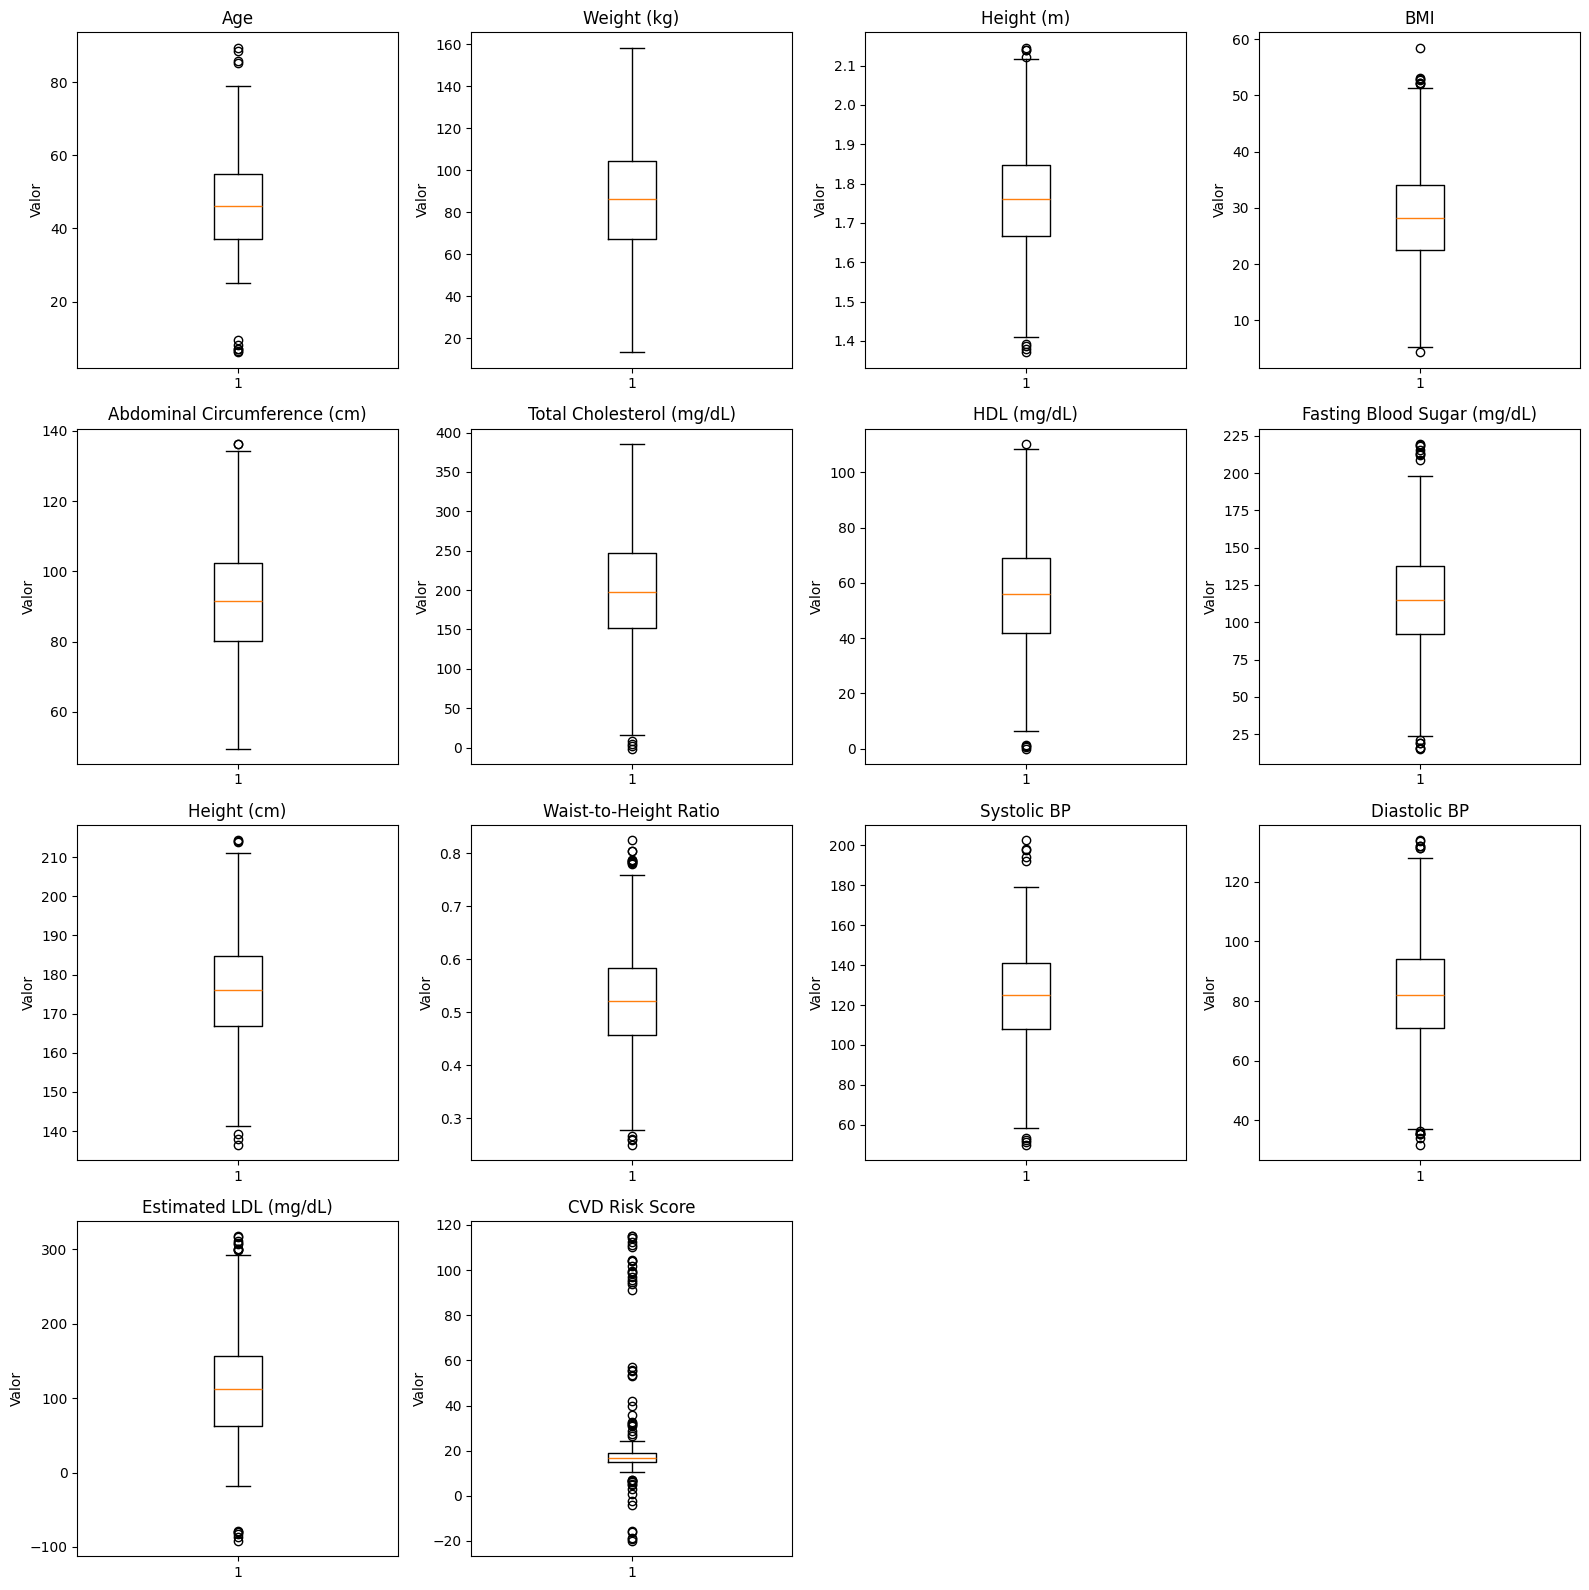

In [326]:
df = datos2.copy()

# columnas numéricas
num_cols = df.select_dtypes(include="number").columns.tolist()

# configuración del layout
n_cols = 4  # número de columnas en la grilla
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

# crear boxplots
for i, c in enumerate(num_cols):
    data = df[c].dropna()

    if not data.empty:
        axes[i].boxplot(data, vert=True)
        axes[i].set_title(c)
        axes[i].set_ylabel("Valor")

# eliminar ejes vacíos si sobran espacios
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

En esta sección se realiza un proceso de validación y corrección de la calidad de los datos numéricos. Primero, se define un conjunto de rangos clínicamente plausibles para cada variable y se identifican valores inválidos, reemplazando números negativos y valores fuera de dichos rangos por valores faltantes (NaN). Posteriormente, se detectan valores atípicos mediante el criterio del rango intercuartílico (IQR × 1.5), los cuales también se consideran inválidos. Finalmente, los valores faltantes generados se imputan utilizando la mediana de cada variable, garantizando un conjunto de datos consistente y completo sin introducir sesgos extremos, y se genera un reporte para verificar que no queden datos faltantes tras la corrección.

In [327]:
df = datos2.copy()


# 1) Define rangos válidos

rangos = {
    "Age": (0, 120),
    "Weight (kg)": (20, 300),
    "Height (m)": (0.9, 2.5),
    "Height (cm)": (90, 250),
    "BMI": (10, 80),
    "Abdominal Circumference (cm)": (40, 200),
    "Waist-to-Height Ratio": (0.2, 1.2),
    "Total Cholesterol (mg/dL)": (50, 500),
    "HDL (mg/dL)": (10, 150),
    "Fasting Blood Sugar (mg/dL)": (40, 400),
    "Systolic BP": (60, 250),
    "Diastolic BP": (30, 150),
    "Estimated LDL (mg/dL)": (0, 400),
    "CVD Risk Score": (0, 100)
}


# 2) Columnas numéricas

num_cols = df.select_dtypes(include="number").columns.tolist()


# 3) Negativos -> NaN

for c in num_cols:
    df.loc[df[c] < 0, c] = np.nan


# 4) Rangos duros -> NaN

for c, (lo, hi) in rangos.items():
    if c in df.columns:
        df.loc[(df[c] < lo) | (df[c] > hi), c] = np.nan


# 5) IQR*1.5 -> NaN (solo para columnas numéricas)

for c in num_cols:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1

    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr

    df.loc[(df[c] < low) | (df[c] > high), c] = np.nan


# 6) Imputar con mediana

for c in num_cols:
    df[c] = df[c].fillna(df[c].median())


# 7) Reporte

faltantes_por_col = df[num_cols].isna().sum().sort_values(ascending=False)
print("Faltantes por columna (después de validar + imputar):")
print(faltantes_por_col)

print("\nFilas con al menos 1 faltante en numéricas:", int(df[num_cols].isna().any(axis=1).sum()))

# Guardar resultado
datos2 = df

Faltantes por columna (después de validar + imputar):
Age                             0
Weight (kg)                     0
Height (m)                      0
BMI                             0
Abdominal Circumference (cm)    0
Total Cholesterol (mg/dL)       0
HDL (mg/dL)                     0
Fasting Blood Sugar (mg/dL)     0
Height (cm)                     0
Waist-to-Height Ratio           0
Systolic BP                     0
Diastolic BP                    0
Estimated LDL (mg/dL)           0
CVD Risk Score                  0
dtype: int64

Filas con al menos 1 faltante en numéricas: 0


### Consistencia

Para la revisión y corregimiento de la consistencia, se va a hacer lo siguiente:

- Normalizar y estandarizar variables categóricas
- Convertir Date of Service a fecha
- Recalcular BMI y Waist-to-Height Ratio usando sus componentes
- Asegurarse de que Systolic BP < Diastolic BP
- Recalcula Blood Pressure Category

In [328]:
df = datos2.copy()


# 0) Helpers

def clean_str(s):
    """Limpia strings: strip + upper. Mantiene NaN."""
    return s.astype(str).str.strip().str.upper().replace({"NAN": np.nan, "NONE": np.nan, "": np.nan})

def map_yes_no(series):
    """Convierte múltiples representaciones a 'Y'/'N'."""
    s = clean_str(series)
    mapping = {
        "Y": "Y", "YES": "Y", "SI": "Y", "SÍ": "Y", "TRUE": "Y", "T": "Y", "1": "Y",
        "N": "N", "NO": "N", "FALSE": "N", "F": "N", "0": "N"
    }
    return s.map(mapping).fillna(s)

def bp_category(sys, dia):
    """Categoría de presión arterial (regla típica AHA 2017)."""
    if pd.isna(sys) or pd.isna(dia):
        return np.nan
    # Crisis hipertensiva (opcional): sys>=180 o dia>=120
    # if sys >= 180 or dia >= 120:
    #     return "HYPERTENSIVE CRISIS"
    if sys < 120 and dia < 80:
        return "NORMAL"
    if 120 <= sys < 130 and dia < 80:
        return "ELEVATED"
    if (130 <= sys < 140) or (80 <= dia < 90):
        return "HYPERTENSION STAGE 1"
    if (sys >= 140) or (dia >= 90):
        return "HYPERTENSION STAGE 2"
    return np.nan


# 1) Consistencia de fechas

if "Date of Service" in df.columns:
    df["Date of Service"] = pd.to_datetime(df["Date of Service"], errors="coerce").dt.normalize()


# 2) Consistencia de categóricas

# Sex -> M/F (todo lo demás queda como NaN u OTHER si prefieres)
if "Sex" in df.columns:
    s = clean_str(df["Sex"])
    sex_map = {"M": "M", "MALE": "M", "F": "F", "FEMALE": "F"}
    df["Sex"] = s.map(sex_map)

# Y/N columns
for col in ["Smoking Status", "Diabetes Status", "Family History of CVD"]:
    if col in df.columns:
        df[col] = map_yes_no(df[col])

# Physical Activity Level
if "Physical Activity Level" in df.columns:
    s = clean_str(df["Physical Activity Level"])
    pal_map = {
        "LOW": "LOW", "BAJO": "LOW",
        "MODERATE": "MODERATE", "MODERADO": "MODERATE",
        "HIGH": "HIGH", "ALTO": "HIGH"
    }
    df["Physical Activity Level"] = s.map(pal_map)

# Blood Pressure Category (solo estandariza texto; luego la recalculamos)
if "Blood Pressure Category" in df.columns:
    s = clean_str(df["Blood Pressure Category"])
    bpc_map = {
        "NORMAL": "NORMAL",
        "ELEVATED": "ELEVATED", "ELEVADA": "ELEVATED",
        "HYPERTENSION STAGE 1": "HYPERTENSION STAGE 1",
        "HYPERTENSION STAGE 2": "HYPERTENSION STAGE 2",
        "HIPERTENSIÓN ETAPA 1": "HYPERTENSION STAGE 1",
        "HIPERTENSION ETAPA 1": "HYPERTENSION STAGE 1",
        "HIPERTENSIÓN ETAPA 2": "HYPERTENSION STAGE 2",
        "HIPERTENSION ETAPA 2": "HYPERTENSION STAGE 2",
    }
    df["Blood Pressure Category"] = s.map(bpc_map).fillna(s)


# 3) Coherencia matemática: alturas, BMI, ratio

# Asegurar numéricos relevantes
for c in ["Height (m)", "Height (cm)", "Weight (kg)", "BMI",
          "Abdominal Circumference (cm)", "Waist-to-Height Ratio",
          "Systolic BP", "Diastolic BP"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Altura: recalcular cm y m para que siempre coincidan
h_m = df["Height (m)"] if "Height (m)" in df.columns else None
h_cm = df["Height (cm)"] if "Height (cm)" in df.columns else None

if h_m is not None and h_cm is not None:
    # Si hay Height(m), fuerza Height(cm)
    m_ok = df["Height (m)"].notna() & (df["Height (m)"] > 0)
    df.loc[m_ok, "Height (cm)"] = df.loc[m_ok, "Height (m)"] * 100

    # Si solo hay Height(cm), fuerza Height(m)
    cm_ok = df["Height (cm)"].notna() & (df["Height (cm)"] > 0)
    df.loc[cm_ok, "Height (m)"] = df.loc[cm_ok, "Height (cm)"] / 100

# BMI: recalcular desde Weight y Height(m)
if all(c in df.columns for c in ["Weight (kg)", "Height (m)", "BMI"]):
    w_ok = df["Weight (kg)"].notna() & (df["Weight (kg)"] > 0)
    hm_ok = df["Height (m)"].notna() & (df["Height (m)"] > 0)
    recalc_mask = w_ok & hm_ok
    df.loc[recalc_mask, "BMI"] = df.loc[recalc_mask, "Weight (kg)"] / (df.loc[recalc_mask, "Height (m)"] ** 2)

# Waist-to-Height Ratio: recalcular desde cintura(cm) y altura(cm)
if all(c in df.columns for c in ["Abdominal Circumference (cm)", "Height (cm)", "Waist-to-Height Ratio"]):
    waist_ok = df["Abdominal Circumference (cm)"].notna() & (df["Abdominal Circumference (cm)"] > 0)
    hcm_ok = df["Height (cm)"].notna() & (df["Height (cm)"] > 0)
    recalc_mask = waist_ok & hcm_ok
    df.loc[recalc_mask, "Waist-to-Height Ratio"] = df.loc[recalc_mask, "Abdominal Circumference (cm)"] / df.loc[recalc_mask, "Height (cm)"]


# 4) Consistencia lógica: presión arterial

fixed_swaps = 0
if all(c in df.columns for c in ["Systolic BP", "Diastolic BP"]):
    swap_mask = df["Systolic BP"].notna() & df["Diastolic BP"].notna() & (df["Systolic BP"] < df["Diastolic BP"])
    fixed_swaps = int(swap_mask.sum())
    # swap
    df.loc[swap_mask, ["Systolic BP", "Diastolic BP"]] = df.loc[swap_mask, ["Diastolic BP", "Systolic BP"]].to_numpy()

# Si existe "Blood Pressure (mmHg)" string, puedes opcionalmente reconstruirla desde sys/dia
if all(c in df.columns for c in ["Systolic BP", "Diastolic BP"]) and "Blood Pressure (mmHg)" in df.columns:
    sys_ok = df["Systolic BP"].notna()
    dia_ok = df["Diastolic BP"].notna()
    mask = sys_ok & dia_ok
    df.loc[mask, "Blood Pressure (mmHg)"] = (
        df.loc[mask, "Systolic BP"].round(0).astype(int).astype(str)
        + "/"
        + df.loc[mask, "Diastolic BP"].round(0).astype(int).astype(str)
    )

# Recalcular Blood Pressure Category desde sys/dia
recalc_cat_count = 0
if all(c in df.columns for c in ["Systolic BP", "Diastolic BP", "Blood Pressure Category"]):
    before = df["Blood Pressure Category"].copy()
    df["Blood Pressure Category"] = df.apply(lambda r: bp_category(r["Systolic BP"], r["Diastolic BP"]), axis=1)
    recalc_cat_count = int((before != df["Blood Pressure Category"]).sum(skipna=False))


# 5) Reporte simple

print("=== REPORTE DE CONSISTENCIA ===")
print("Swaps hechos (Systolic < Diastolic):", fixed_swaps)
if "Blood Pressure Category" in df.columns:
    print("Cambios en Blood Pressure Category (aprox):", recalc_cat_count)

# Valores únicos (para revisar rápido)
for col in ["Sex", "Smoking Status", "Diabetes Status", "Family History of CVD", "Physical Activity Level", "Blood Pressure Category"]:
    if col in df.columns:
        print(f"\nValores únicos en {col}:")
        print(df[col].value_counts(dropna=False))

# Guardar resultado
datos2 = df


=== REPORTE DE CONSISTENCIA ===
Swaps hechos (Systolic < Diastolic): 52
Cambios en Blood Pressure Category (aprox): 11

Valores únicos en Sex:
Sex
F    676
M    668
Name: count, dtype: int64

Valores únicos en Smoking Status:
Smoking Status
Y    691
N    653
Name: count, dtype: int64

Valores únicos en Diabetes Status:
Diabetes Status
Y    679
N    665
Name: count, dtype: int64

Valores únicos en Family History of CVD:
Family History of CVD
N    685
Y    659
Name: count, dtype: int64

Valores únicos en Physical Activity Level:
Physical Activity Level
HIGH        462
MODERATE    449
LOW         433
Name: count, dtype: int64

Valores únicos en Blood Pressure Category:
Blood Pressure Category
HYPERTENSION STAGE 2    552
HYPERTENSION STAGE 1    445
NORMAL                  258
ELEVATED                 89
Name: count, dtype: int64


## 2. Transformación de los datos y construcción de pipeline

Se crea una copia del dataset y se define la variable objetivo (CVD Risk Score) junto con las variables predictoras seleccionadas. Posteriormente, se separan las características (X) y la variable a predecir (y).

In [329]:
data = datos2.copy()

target = "CVD Risk Score"

feature_cols = [
    "Age",
    "Sex",
    "Smoking Status",
    "Diabetes Status",
    "Family History of CVD",
    "Physical Activity Level",
    "BMI",
    "Abdominal Circumference (cm)",
    "Systolic BP",
    "Diastolic BP",
    "Estimated LDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)",
]

X = data[feature_cols].copy()
y = data[target].copy()


El conjunto de datos se divide en entrenamiento (75%) y prueba (25%) para evaluar el modelo de forma objetiva. Además, se muestran las dimensiones resultantes de cada subconjunto.

In [330]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1008, 12), (336, 12), (1008,), (336,))

Se define una función de limpieza que convierte variables binarias a formato numérico (1/0) y estandariza valores categóricos como sexo y nivel de actividad física para asegurar consistencia en los datos. Esta función se integra en un FunctionTransformer para usarla dentro de un pipeline.

In [331]:
def limpiar_columnas(df):
    df = df.copy()

    # Asegurar Y/N -> 1/0 (por si aún quedara en texto)
    yn_cols = ["Smoking Status", "Diabetes Status", "Family History of CVD"]
    mapping = {"Y": 1, "N": 0, "YES": 1, "NO": 0, "TRUE": 1, "FALSE": 0, "1": 1, "0": 0}

    for col in yn_cols:
        if col in df.columns:
            s = df[col]

            # Si viene como texto, mapeamos. Si viene numérico, lo dejamos como número.
            if pd.api.types.is_string_dtype(s) or s.dtype == "object":
                s = s.astype(str).str.strip().str.upper()
                df[col] = s.map(mapping).astype(float)
            else:
                df[col] = pd.to_numeric(s, errors="coerce")

    # Estandarizar Sex y Physical Activity Level (por si hay variaciones)
    if "Sex" in df.columns:
        df["Sex"] = df["Sex"].astype(str).str.strip().str.upper().replace({"MALE":"M", "FEMALE":"F", "NAN": np.nan})

    if "Physical Activity Level" in df.columns:
        df["Physical Activity Level"] = (
            df["Physical Activity Level"].astype(str).str.strip().str.upper()
            .replace({"MODERADO":"MODERATE", "BAJO":"LOW", "ALTO":"HIGH", "NAN": np.nan})
        )

    return df

limpieza = FunctionTransformer(limpiar_columnas)

Se vuelve a definir la misma función de limpieza y se encapsula nuevamente como transformador, permitiendo aplicar automáticamente la estandarización y codificación de variables durante el flujo de preprocesamiento del modelo.

In [332]:
numeric_features = [
    "Age",
    "BMI",
    "Abdominal Circumference (cm)",
    "Systolic BP",
    "Diastolic BP",
    "Estimated LDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)",
    "Smoking Status",
    "Diabetes Status",
    "Family History of CVD",
]

categorical_features = ["Sex", "Physical Activity Level"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

pipeline_regresion = Pipeline(steps=[
    ("limpieza", limpieza),
    ("preprocesamiento", preprocessor),
])

## 3. Entrenamiento 

Se aplica el pipeline de preprocesamiento al conjunto de entrenamiento y se transforman las variables para dejarlas listas para el modelo. Luego, se entrena un modelo de regresión lineal utilizando las características transformadas.

In [333]:
Xt_train = pipeline_regresion.fit_transform(X_train)

feature_names = pipeline_regresion.named_steps["preprocesamiento"].get_feature_names_out()

Xt_train_df = pd.DataFrame(
    Xt_train.toarray() if hasattr(Xt_train, "toarray") else Xt_train,
    columns=feature_names,
    index=X_train.index
)

Modelo = LinearRegression()
Modelo.fit(Xt_train_df, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Validación del modelo

Se generan predicciones sobre el conjunto de entrenamiento y se calculan las métricas MAE, RMSE y R² para evaluar el desempeño del modelo durante la fase de entrenamiento.

In [334]:
y_train_pred = Modelo.predict(Xt_train_df)

mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

mae_train_m2 = mae_train
rmse_train_m2 = rmse_train
r2_train_m2 = r2_train

print("MAE  train:", mae_train)
print("RMSE train:", rmse_train)
print("R²   train:", r2_train)

MAE  train: 0.8998411971290404
RMSE train: 1.2259286182481122
R²   train: 0.7533479868628499


Los resultados obtenidos sobre el conjunto de entrenamiento indican que el modelo presenta un buen nivel de ajuste a los datos, con un MAE de aproximadamente 0.90 y un RMSE de 1.23, lo que sugiere que las predicciones se mantienen cercanas a los valores reales en promedio. Asimismo, el coeficiente de determinación (R² = 0.75) evidencia que el modelo logra explicar cerca del 75% de la variabilidad del riesgo cardiovascular, mostrando una capacidad predictiva sólida durante el entrenamiento. Sin embargo, este desempeño debe contrastarse posteriormente con los resultados sobre el conjunto de prueba para verificar que el modelo generaliza adecuadamente y no incurre en sobreajuste.

## 4. Estimación

### Validación del modelo

In [335]:
Xt_test = pipeline_regresion.transform(X_test)

Xt_test_df = pd.DataFrame(
    Xt_test.toarray() if hasattr(Xt_test, "toarray") else Xt_test,
    columns=feature_names,
    index=X_test.index
)

y_test_pred = Modelo.predict(Xt_test_df)

mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

mae_test_m2 = mae_test
rmse_test_m2 = rmse_test
r2_test_m2 = r2_test

print("MAE  test :", mae_test)
print("RMSE test :", rmse_test)
print("R²   test :", r2_test)

MAE  test : 0.96288938734124
RMSE test : 1.4281820848775109
R²   test : 0.6545926668254558


Los resultados obtenidos sobre el conjunto de prueba muestran que el modelo mantiene un desempeño predictivo adecuado fuera de los datos utilizados para el entrenamiento, con un MAE cercano a 0.96 y un RMSE de 1.43, lo que indica un nivel de error moderado en las predicciones. El coeficiente de determinación (R² = 0.65) evidencia que el modelo explica aproximadamente el 65% de la variabilidad del riesgo cardiovascular en datos no vistos previamente. Aunque se observa una ligera disminución del rendimiento respecto al conjunto de entrenamiento, este comportamiento es esperado y sugiere que el modelo generaliza razonablemente bien sin presentar señales significativas de sobreajuste.

## 5. Verificación de supuestos

La evaluación de los supuestos del modelo permite interpretar adecuadamente los coeficientes obtenidos en la regresión lineal. Recordemos que un modelo de regresión lineal puede expresarse de la siguiente forma:

$$
y = \beta_{0} + \beta_{1}x_{1} + \beta_{2}x_{2} + \cdots + \beta_{n}x_{n}
$$

donde $\beta_{0}$ corresponde al intercepto (o término constante) y $\beta_{1}, \beta_{2}, \ldots, \beta_{n}$ representan los coeficientes asociados a cada variable explicativa incluida en el modelo.

En este contexto, dichos coeficientes indican cuánto cambia la estimación del **CVD Risk Score** ante variaciones en cada variable predictora, manteniendo constantes las demás variables. Por esta razón, analizar los coeficientes estimados permite comprender la influencia relativa de los factores clínicos y demográficos considerados en la predicción del riesgo cardiovascular. A continuación, se presentan los coeficientes obtenidos por el modelo entrenado.

In [336]:
print("Intercepto:", Modelo.intercept_)

clean_names = [
    n.replace("num__", "").replace("cat__", "")
    for n in feature_names
]

coef_df = pd.DataFrame({
    "Variable": clean_names,
    "Coeficiente": Modelo.coef_
}).sort_values("Coeficiente", key=np.abs, ascending=False)

coef_df

Intercepto: 16.925909649109062


,Variable,Coeficiente
3,Systolic BP,1.071824
5,Estimated LDL (mg/dL),1.069795
8,Diabetes Status,1.027533
1,BMI,0.953797
12,Physical Activity Level_LOW,-0.094598
13,Physical Activity Level_MODERATE,0.060559
9,Family History of CVD,0.049488
2,Abdominal Circumference (cm),0.045368
4,Diastolic BP,0.039951
11,Physical Activity Level_HIGH,0.034039


Los coeficientes de la regresión lineal indican cuánto cambia, en promedio, el 'CVD Risk Score' cuando una variable independiente aumenta en una unidad, manteniendo constantes las demás variables del modelo. Un coeficiente positivo sugiere que el riesgo cardiovascular estimado tiende a incrementarse al aumentar dicha variable, mientras que un coeficiente negativo indica una relación inversa. La magnitud del coeficiente refleja la intensidad de este efecto sobre la predicción. Por su parte, el intercepto representa el valor estimado del riesgo cardiovascular cuando todas las variables independientes toman el valor cero; aunque este escenario no sea clínicamente realista, es necesario desde el punto de vista matemático para definir el modelo de regresión.

Se observa que variables clínicas como 'Systolic BP', 'Estimated LDL (mg/dL)' y 'Diabetes Status' presentan los coeficientes positivos más altos, lo que indica que tienen la mayor influencia en el incremento del riesgo cardiovascular estimado. Asimismo, el BMI muestra un efecto relevante, sugiriendo que mayores niveles de índice de masa corporal se asocian con un mayor riesgo. En contraste, algunas categorías del nivel de actividad física, como 'Physical Activity Level_LOW', presentan coeficientes negativos, lo que indica una ligera reducción en la predicción del riesgo en comparación con la categoría de referencia. Variables como edad, sexo y hábitos de tabaquismo muestran coeficientes de menor magnitud, lo que sugiere un impacto relativamente menor dentro del modelo frente a los indicadores fisiológicos y metabólicos principales.

### Multicolinealidad

La multicolinealidad ocurre cuando dos o más variables predictoras están altamente correlacionadas entre sí, lo que puede afectar la estabilidad y la interpretación de los coeficientes en un modelo de regresión lineal. Para evaluarla se utiliza el **Factor de Inflación de la Varianza (VIF)**, el cual mide cuánto aumenta la varianza de un coeficiente debido a su relación con las demás variables explicativas.

Valores de VIF cercanos a 1 indican baja correlación entre variables, mientras que valores elevados sugieren posible multicolinealidad y menor confiabilidad en la interpretación de los coeficientes. En general, se considera que existe un problema relevante cuando **VIF ≥ 4 o 5**.

$$
VIF = \frac{1}{1 - R^2}
$$

En este análisis se calcula un valor de VIF para cada variable predictora con el fin de verificar si las variables clínicas utilizadas para estimar el **CVD Risk Score** presentan problemas de multicolinealidad.

In [337]:
# 1) Tomar solo columnas numéricas del diseño ya transformado
X_vif = Xt_train_df.select_dtypes(include="number").copy()

# 2) Limpiar nombres (por si vienen de pipeline)
clean_columns = (
    X_vif.columns.astype(str)
        .str.replace("^num__", "", regex=True)
        .str.replace("^cat__", "", regex=True)
        .str.replace("^preprocesamiento__", "", regex=True)
)

# 3) Quitar columnas constantes o casi constantes (evita VIF inf / NaN)
std = X_vif.std(axis=0)
keep = std[std > 0].index
X_vif = X_vif[keep]
clean_columns = clean_columns[[c in keep for c in Xt_train_df.columns.astype(str)]]

# 4) Calcular VIF
vif_values = []
with np.errstate(divide="ignore", invalid="ignore"):
    for i in range(X_vif.shape[1]):
        vif_values.append(variance_inflation_factor(X_vif.values, i))

vif_data = pd.DataFrame({
    "Variable": clean_columns.values,
    "VIF": vif_values
}).sort_values("VIF", ascending=False)

# 5) Mostrar resultados
display(vif_data.head(20))
print("\nNúmero de variables con VIF ≥ 5:", (vif_data["VIF"] >= 5).sum())
print("Número de variables con VIF ≥ 10:", (vif_data["VIF"] >= 10).sum())

,Variable,VIF
13,Physical Activity Level_MODERATE,1.341804
11,Physical Activity Level_HIGH,1.332798
12,Physical Activity Level_LOW,1.278180
3,Systolic BP,1.038817
4,Diastolic BP,1.035283
0,Age,1.034739
6,Fasting Blood Sugar (mg/dL),1.031765
2,Abdominal Circumference (cm),1.021632
5,Estimated LDL (mg/dL),1.016891
8,Diabetes Status,1.013673



Número de variables con VIF ≥ 5: 0
Número de variables con VIF ≥ 10: 0


Los valores de VIF obtenidos son cercanos a 1 para todas las variables, lo que indica una baja correlación entre las variables predictoras y, por tanto, ausencia de problemas de multicolinealidad en el modelo. Esto sugiere que los coeficientes estimados son estables y pueden interpretarse de manera confiable, ya que ninguna variable presenta redundancia significativa con las demás.

### Normalidad de los errores

Este supuesto establece que los errores del modelo, es decir, la diferencia entre el **CVD Risk Score** real y el valor predicho por la regresión, deberían seguir aproximadamente una distribución normal. En términos prácticos, esto implica que la mayoría de los errores deben ser pequeños, mientras que los errores grandes deben ser poco frecuentes y distribuirse de manera simétrica alrededor de cero.

El cumplimiento de este supuesto permite realizar inferencias estadísticas confiables sobre el modelo y sus coeficientes. Para evaluarlo, pueden utilizarse pruebas de normalidad, como la prueba de **Shapiro–Wilk**, además de análisis gráficos de la distribución de los residuos.

Prueba Shapiro-Wilk
---------------------
Estadístico: 0.9718091569568257
p-value: 4.416524905626025e-13
⚠️ Los errores no siguen distribución normal


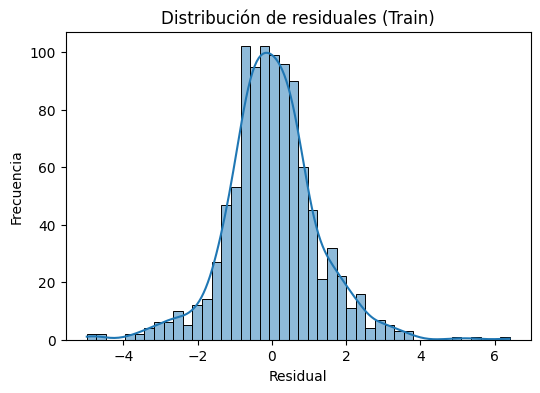

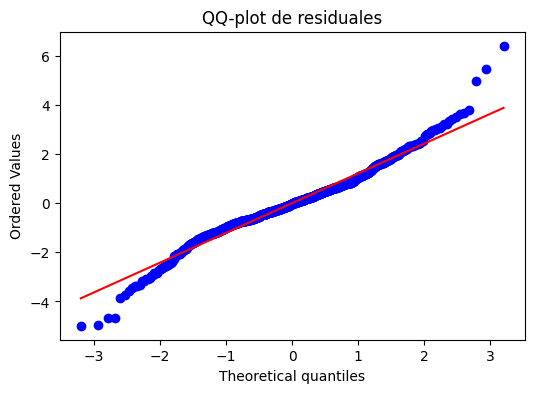

In [338]:

# Residuales del modelo (TRAIN)


# errores = valor real - predicción
residuales = y_train - y_train_pred
residuales = residuales.dropna()


# Prueba de normalidad Shapiro-Wilk


stat, p_shapiro = shapiro(residuales)

print("Prueba Shapiro-Wilk")
print("---------------------")
print("Estadístico:", stat)
print("p-value:", p_shapiro)

if p_shapiro > 0.05:
    print("✅ No se rechaza normalidad de los errores")
else:
    print("⚠️ Los errores no siguen distribución normal")


# Histograma de residuales


plt.figure(figsize=(6,4))
sns.histplot(residuales, kde=True)
plt.title("Distribución de residuales (Train)")
plt.xlabel("Residual")
plt.ylabel("Frecuencia")
plt.show()


# QQ-Plot


plt.figure(figsize=(6,4))
stats.probplot(residuales, dist="norm", plot=plt)
plt.title("QQ-plot de residuales")
plt.show()

Aunque la prueba de Shapiro–Wilk rechaza formalmente la normalidad de los residuales, el análisis gráfico muestra que la distribución es aproximadamente simétrica y cercana a una forma normal en la región central. El histograma presenta una estructura tipo campana y el QQ-plot evidencia alineación con la recta teórica salvo ligeras desviaciones en las colas, lo cual es común en datos reales. Por tanto, el supuesto de normalidad puede considerarse razonablemente satisfecho para fines prácticos del modelo.

### Homocedasticidad

Este supuesto establece que los errores del modelo deben presentar una variabilidad aproximadamente constante a lo largo de todos los niveles de las variables explicativas, es decir, que el modelo cometa errores de magnitud similar para pacientes con distintos niveles de riesgo cardiovascular estimado. Cuando este supuesto no se cumple, se presenta **heterocedasticidad**, lo que implica que los errores estándar de los coeficientes pueden estar mal estimados y, por tanto, las pruebas estadísticas utilizadas para evaluar la significancia de las variables pueden resultar poco confiables.

Una forma común de evaluar este supuesto es mediante la prueba de **Breusch–Pagan**, la cual permite detectar si la varianza de los errores depende sistemáticamente de las variables explicativas del modelo.

In [339]:

# Matriz numérica del modelo

X_num = Xt_train_df.select_dtypes(include="number").copy()

# Alinear índices entre X y residuales
data_bp = X_num.copy()
data_bp["residuales"] = residuales

# Eliminar filas con valores no finitos
data_bp = data_bp.replace([np.inf, -np.inf], np.nan).dropna()

resid_clean = data_bp["residuales"]
X_num_clean = data_bp.drop(columns="residuales")

# Agregar constante (requerido por statsmodels)
X_num_const = sm.add_constant(X_num_clean)


# Test Breusch-Pagan

bp_stat, bp_pvalue, _, _ = het_breuschpagan(resid_clean, X_num_const)

print("Prueba Breusch-Pagan")
print("----------------------")
print("Estadístico:", bp_stat)
print("p-value   :", bp_pvalue)

if bp_pvalue > 0.05:
    print("✅ No hay evidencia de heterocedasticidad (homocedasticidad aceptable)")
else:
    print("⚠️ Existe evidencia de heterocedasticidad")

Prueba Breusch-Pagan
----------------------
Estadístico: 32.288165571517006
p-value   : 0.003644763126019355
⚠️ Existe evidencia de heterocedasticidad


La prueba de Breusch–Pagan arroja un p-value menor a 0.05, por lo que se rechaza la hipótesis nula de homocedasticidad. Esto indica que la varianza de los errores no es constante y que existe evidencia de heterocedasticidad en el modelo. En consecuencia, aunque la capacidad predictiva del modelo no se ve necesariamente afectada, las estimaciones de los errores estándar y las pruebas de significancia de los coeficientes pueden no ser completamente confiables, por lo que los resultados inferenciales deben interpretarse con cautela.

### Independencia de los errores

El supuesto de independencia establece que los errores del modelo deben ser independientes entre sí; es decir, el error cometido al predecir el **CVD Risk Score** de un paciente no debería influir en el error de otro registro. Si este supuesto no se cumple, se presenta **autocorrelación**, lo cual puede hacer que las pruebas de inferencia sobre el modelo (por ejemplo, significancia de coeficientes) sean menos confiables.

Una forma común de evaluar este supuesto es mediante el estadístico de **Durbin–Watson (DW)**, cuyo rango es:

$$0 \le DW \le 4$$

- Valores cercanos a **0** sugieren autocorrelación **positiva**.  
- Un valor cercano a **2** indica ausencia de autocorrelación.  
- Valores cercanos a **4** sugieren autocorrelación **negativa**.  

In [340]:
dw = durbin_watson(residuales)
print("Durbin-Watson:", dw)

Durbin-Watson: 2.0063857151240376


El estadístico de Durbin–Watson obtenido es aproximadamente 2.01, valor muy cercano a 2, lo que indica ausencia de autocorrelación en los errores del modelo. Esto sugiere que los residuales son independientes entre sí y que el supuesto de independencia de los errores se cumple adecuadamente, permitiendo confiar en la validez de las inferencias estadísticas realizadas sobre el modelo.

### Linealidad

El supuesto de linealidad establece que la relación entre las variables explicativas y la media del **CVD Risk Score** puede describirse adecuadamente mediante una combinación lineal de las variables predictoras. Esto implica que cada variable contribuye con un efecto aproximadamente proporcional y constante sobre el riesgo cardiovascular estimado cuando aumenta en una unidad, manteniendo las demás variables fijas.

Una forma de evaluar este supuesto es mediante pruebas estadísticas como el **test de Rainbow**, el cual permite verificar si el modelo lineal se ajusta adecuadamente a los datos o si existen indicios de relaciones no lineales que el modelo no está capturando correctamente.

In [341]:
X_sm = sm.add_constant(Xt_train_df)
modelo_sm = sm.OLS(y_train, X_sm).fit()

rainbow_stat, rainbow_pvalue = linear_rainbow(modelo_sm)

print("Estadístico Rainbow:", rainbow_stat)
print("p-value Rainbow    :", rainbow_pvalue)

Estadístico Rainbow: 0.8316718316490369
p-value Rainbow    : 0.9799714798557126


El test de Rainbow arroja un p-value considerablemente mayor a 0.05, por lo que no se rechaza la hipótesis nula de linealidad. Esto indica que no existe evidencia estadística de relaciones no lineales relevantes entre las variables explicativas y el CVD Risk Score, sugiriendo que el modelo de regresión lineal describe adecuadamente la relación entre las variables predictoras y la variable objetivo.

## 6. Análisis de la tabla de coeficientes después de los supuestos

In [342]:
print("Intercepto:", Modelo.intercept_)

clean_names = [
    n.replace("num__", "").replace("cat__", "")
    for n in feature_names
]

coef_df = pd.DataFrame({
    "Variable": clean_names,
    "Coeficiente": Modelo.coef_
}).sort_values("Coeficiente", key=np.abs, ascending=False)

coef_df

Intercepto: 16.925909649109062


,Variable,Coeficiente
3,Systolic BP,1.071824
5,Estimated LDL (mg/dL),1.069795
8,Diabetes Status,1.027533
1,BMI,0.953797
12,Physical Activity Level_LOW,-0.094598
13,Physical Activity Level_MODERATE,0.060559
9,Family History of CVD,0.049488
2,Abdominal Circumference (cm),0.045368
4,Diastolic BP,0.039951
11,Physical Activity Level_HIGH,0.034039


A partir del modelo seleccionado se construyó una tabla de coeficientes que permite analizar la importancia relativa de cada variable en la predicción del CVD Risk Score. En un modelo de regresión lineal, los coeficientes representan el cambio esperado en la variable objetivo ante una variación unitaria de cada predictor, manteniendo constantes las demás variables. La interpretación de estos coeficientes resulta válida dado que los principales supuestos del modelo fueron evaluados previamente: no se evidenció multicolinealidad significativa (VIF cercanos a 1), la independencia de los errores se cumplió según el estadístico de Durbin–Watson, la linealidad fue confirmada mediante el test de Rainbow y la normalidad de los residuos se considera razonablemente satisfecha desde el análisis gráfico. Aunque se detectó heterocedasticidad, esta afecta principalmente la inferencia estadística y no la capacidad predictiva del modelo. En este contexto, los coeficientes pueden interpretarse de manera confiable, identificando como variables más influyentes factores clínicos como la presión arterial sistólica, el LDL estimado, el estado de diabetes y el índice de masa corporal, lo cual resulta coherente con el conocimiento médico sobre el riesgo cardiovascular.

# Tabla comparativa

In [343]:
import pandas as pd
import numpy as np


# 1) REGISTRO DE RESULTADOS (usa tus variables ya calculadas)
#    Asegúrate de tener definidas:
#    mae_train_m1, rmse_train_m1, r2_train_m1, mae_test_m1, rmse_test_m1, r2_test_m1
#    mae_train_m2, rmse_train_m2, r2_train_m2, mae_test_m2, rmse_test_m2, r2_test_m2

resultados = {
    "Modelo 1": {
        ("Train","MAE"): mae_train_m1, ("Train","RMSE"): rmse_train_m1, ("Train","R²"): r2_train_m1,
        ("Test","MAE"):  mae_test_m1,  ("Test","RMSE"):  rmse_test_m1,  ("Test","R²"):  r2_test_m1,
    },
    "Modelo 2": {
        ("Train","MAE"): mae_train_m2, ("Train","RMSE"): rmse_train_m2, ("Train","R²"): r2_train_m2,
        ("Test","MAE"):  mae_test_m2,  ("Test","RMSE"):  rmse_test_m2,  ("Test","R²"):  r2_test_m2,
    },
}

tabla = pd.DataFrame.from_dict(resultados, orient="index")
tabla.columns = pd.MultiIndex.from_tuples(tabla.columns)


# 2) RANKING AUTOMÁTICO (solo con métricas de TEST)
#    - MAE/RMSE: menor es mejor
#    - R²: mayor es mejor
#    Score compuesto: promedio de ranks en TEST

rank_mae  = tabla[("Test","MAE")].rank(ascending=True)
rank_rmse = tabla[("Test","RMSE")].rank(ascending=True)
rank_r2   = tabla[("Test","R²")].rank(ascending=False)

tabla[("Test","Score (rank)")] = (rank_mae + rank_rmse + rank_r2) / 3
tabla = tabla.sort_values(("Test","Score (rank)"), ascending=True)

best_model = tabla.index[0]
tabla[("Modelo","Mejor")] = np.where(tabla.index == best_model, "🏆 Best", "")

# Reordenar columnas para presentación
orden_cols = [
    ("Modelo","Mejor"),
    ("Train","MAE"), ("Train","RMSE"), ("Train","R²"),
    ("Test","MAE"),  ("Test","RMSE"),  ("Test","R²"),
    ("Test","Score (rank)")
]
tabla = tabla[orden_cols].copy()

idx = pd.IndexSlice

# Para que los gradientes tengan sentido:
# - errores: invertimos el colormap (menor = más azul)
# - R²: normal (mayor = más azul)
styled = (
    tabla.style
    .format({
        ("Train","MAE"): "{:.3f}", ("Train","RMSE"): "{:.3f}", ("Train","R²"): "{:.3f}",
        ("Test","MAE"):  "{:.3f}", ("Test","RMSE"):  "{:.3f}", ("Test","R²"):  "{:.3f}",
        ("Test","Score (rank)"): "{:.2f}",
    })
    .set_caption("Tabla comparativa de desempeño (Train vs Test) — selección automática del mejor modelo")
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "14px"), ("margin-bottom", "10px")]},
        {"selector": "th", "props": [("text-align", "center"), ("padding", "6px")]},
        {"selector": "td", "props": [("text-align", "center"), ("padding", "6px")]},
        {"selector": "thead th", "props": [("border-bottom", "1px solid #ddd")]},
    ])
    # Azul suave para errores (menor mejor)
    .background_gradient(cmap="Blues_r", subset=idx[:, [("Train","MAE"), ("Train","RMSE"), ("Test","MAE"), ("Test","RMSE")]])
    # Azul suave para R² (mayor mejor)
    .background_gradient(cmap="Blues", subset=idx[:, [("Train","R²"), ("Test","R²")]])
    # Azul suave para score (menor mejor)
    .background_gradient(cmap="Blues_r", subset=idx[:, [("Test","Score (rank)")]])
)

styled

La comparación entre modelos evidencia diferencias claras en términos de sesgo y capacidad predictiva. El Modelo 1 presenta errores elevados y un R² cercano a cero tanto en entrenamiento como en prueba, lo que indica un caso de subajuste, donde el modelo no logra capturar la relación subyacente entre las variables clínicas y el riesgo cardiovascular. En contraste, el Modelo 2 reduce significativamente el MAE y el RMSE y alcanza valores altos de R², manteniendo un desempeño consistente entre entrenamiento (0.75) y prueba (0.65). Esta estabilidad sugiere un equilibrio adecuado entre sesgo y varianza, así como una correcta generalización a datos no observados. Por ello, el Modelo 2 constituye la mejor alternativa para la tarea de predicción planteada.

# Nueva Columna

El código carga el archivo Datos Test Lab 1.csv, selecciona únicamente las variables utilizadas durante el entrenamiento del modelo y aplica el mismo proceso de limpieza previamente definido para asegurar que las categorías y valores tengan el formato correcto (por ejemplo, convertir variables binarias a formato numérico). Posteriormente, los datos se transforman mediante el pipeline de preprocesamiento ya entrenado —sin volver a ajustarlo— para garantizar que las nuevas observaciones reciban exactamente las mismas transformaciones aplicadas en el entrenamiento. Luego, se reconstruye la matriz de características con los mismos nombres de columnas que vio el modelo original y se generan las predicciones del CVD Risk Score usando la regresión lineal entrenada. Finalmente, las predicciones se agregan como una nueva columna al dataset, se muestran algunos resultados para verificación y se guarda el archivo actualizado con los valores estimados.

In [344]:
datos_test = pd.read_csv("data/Datos Test Lab 1.csv", sep=";")

feature_cols = [
    "Age",
    "Sex",
    "Smoking Status",
    "Diabetes Status",
    "Family History of CVD",
    "Physical Activity Level",
    "BMI",
    "Abdominal Circumference (cm)",
    "Systolic BP",
    "Diastolic BP",
    "Estimated LDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)",
]

X_new = datos_test[feature_cols].copy()

# aplica la MISMA limpieza que usaste en el pipeline (Y/N -> 1/0, estandariza categorías)
# (esto asume que ya tienes definida la función limpiar_columnas en tu notebook)
X_new = limpiar_columnas(X_new)

# transforma con el pipeline entrenado (sin fit)
Xt_new = pipeline_regresion.transform(X_new)

# mismas columnas que el modelo vio en entrenamiento
feature_names = pipeline_regresion.named_steps["preprocesamiento"].get_feature_names_out()

Xt_new_df = pd.DataFrame(
    Xt_new.toarray() if hasattr(Xt_new, "toarray") else Xt_new,
    columns=feature_names,
    index=X_new.index
)

# predice con tu LinearRegression ya entrenado
datos_test["CVD Risk Score"] = Modelo.predict(Xt_new_df)

print(datos_test[["Patient ID", "CVD Risk Score"]].head())

datos_test.to_csv("data/Datos Test Lab 1_con_predicciones.csv", sep=";", index=False)

  Patient ID  CVD Risk Score
0   WYTG8678       16.269822
1   yloc1993       15.924433
2   DDwq7653       16.774762
3   YTcX6704       14.082089
4   lZLi8935       12.221679


Columnas del dataset:
Index(['Patient ID', 'Date of Service', 'Sex', 'Age', 'Weight (kg)',
       'Height (m)', 'BMI', 'Abdominal Circumference (cm)',
       'Blood Pressure (mmHg)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)',
       'Fasting Blood Sugar (mg/dL)', 'Smoking Status', 'Diabetes Status',
       'Physical Activity Level', 'Family History of CVD', 'Height (cm)',
       'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP',
       'Blood Pressure Category', 'Estimated LDL (mg/dL)', 'CVD Risk Score'],
      dtype='str')

----------------------------------
Resumen estadístico:
count    194.000000
mean      16.988440
std        2.028590
min       11.173526
25%       15.657569
50%       16.918888
75%       18.290267
max       21.752753
Name: CVD Risk Score, dtype: float64

----------------------------------
Valores faltantes: 0

----------------------------------
Valor mínimo: 11.173525555133793
Valor máximo: 21.752753399639634

----------------------------------
  Patient ID  C

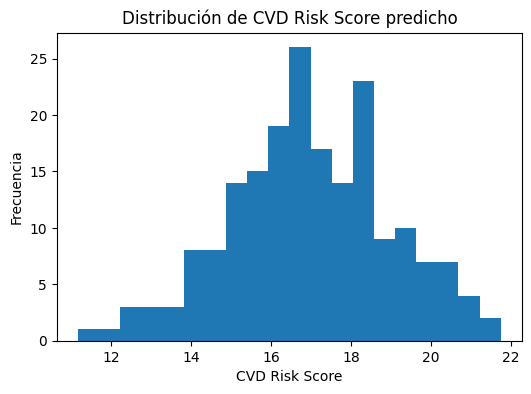

In [345]:
# 1. Confirmar que la columna existe
print("Columnas del dataset:")
print(datos_test.columns)

print("\n----------------------------------")

# 2. Revisar valores básicos
print("Resumen estadístico:")
print(datos_test["CVD Risk Score"].describe())

print("\n----------------------------------")

# 3. Revisar valores faltantes
faltantes = datos_test["CVD Risk Score"].isna().sum()
print("Valores faltantes:", faltantes)

print("\n----------------------------------")

# 4. Revisar valores extremos
print("Valor mínimo:", datos_test["CVD Risk Score"].min())
print("Valor máximo:", datos_test["CVD Risk Score"].max())

print("\n----------------------------------")

# 5. Ver algunas predicciones
print(datos_test[["Patient ID", "CVD Risk Score"]].head())

print("\n----------------------------------")

# 6. Visualizar distribución (sanity check visual)
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(datos_test["CVD Risk Score"], bins=20)
plt.title("Distribución de CVD Risk Score predicho")
plt.xlabel("CVD Risk Score")
plt.ylabel("Frecuencia")
plt.show()

Las predicciones del CVD Risk Score generadas sobre el conjunto de datos de prueba presentan valores completos y coherentes, sin registros faltantes. La distribución de los valores predichos muestra un comportamiento aproximadamente normal y un rango consistente con los datos de entrenamiento, lo que indica que el modelo generaliza adecuadamente a nuevos pacientes y produce estimaciones estables del riesgo cardiovascular.

# Análisis de resultados

1. ¿Cuál fue el valor de los diferentes coeficientes obtenidos en el mejor modelo?

Para el mejor modelo, se obtuvieron los siguientes coeficientes para sus variables respectivas:

| **Variables**                    | **Coeficientes** |
| -------------------------------- | ---------------- |
| Systolic BP                      | 1.071824         |
| Estimated LDL (mg/dL)            | 1.069795         |
| Diabetes Status                  | 1.027533         |
| BMI                              | 0.953797         |
| Physical Activity Level_LOW      | -0.094598        |
| Physical Activity Level_MODERATE | 0.060559         |
| Family History of CVD            | 0.049488         |
| Abdominal Circumference (cm)     | 0.045368         |
| Diastolic BP                     | 0.039951         |
| Physical Activity Level_HIGH     | 0.034039         |
| Smoking Status                   | 0.027978         |
| Fasting Blood Sugar (mg/dL)      | 0.025300         |
| Age                              | 0.005208         |
| Sex_M                            | -0.003431        |

2. A partir de la tabla comparativa, ¿cuál modelo ofrece el mejor rendimiento sobre el conjunto test? ¿Qué interpretación puedes darles a los valores obtenidos sobre las métricas de rendimiento?

A partir de la tabla coparativa se puede ver claramente que el modelo 2 es e modelo que ofrece el mejor rendimiento sobre el conjunto test. Principalmente, se puede ver un R^2 superior a 0.6 Esto significa que el modelo hace predicciones relativamente buenas basado en los datos que se le ofrecen. Además, el MAE y el RMSE es reducido significativamente, reforzando la idea de que el modelo 2 es superior. Se puede ver un equilibrio adecuado entre sesgo y varianza, mucho mejor que el del modelo 1.

3. ¿Cuáles variables fueron seleccionadas con el modelo seleccionado? A partir de estas, ¿qué interpretación de cara al problema puedes dar? Reflexiona sobre cómo este nuevo conocimiento podría ayudar a tomar decisiones en el contexto del problema.

No todas las variables que venían en los datos fueron seleccionadas. Una de las más importantes de eliminar era CVD Risk Level, ya que esta era derivada del CVD Risk Score y no tendría sentido incluirla. Podría afectar los resultados de manera negativa. Adicionalmente, habían variables que provenían de otras variables dentro de los datos. Por ejemplo, Blood Pressure Category. Aquí se podía tomar la decisión de dejar la 'variable resultado' o las variables que componen dicha 'variable resultado'. En el caso de este modelo, se incluyeron las 'variables respuesta' sin incluir sus componentes. Esto se puede ber en el caso de BMI. Excluir los componentes es sumamente importante para evitar redundancias y que los resultados se vean afectados.

Las variables seleccionadas para el modelo seleccionado fueron las siguientes:

| Systolic BP                      |
| -------------------------------- |
| Estimated LDL (mg/dL)            |
| Diabetes Status                  |
| BMI                              |
| Physical Activity Level_LOW      |
| Physical Activity Level_MODERATE |
| Family History of CVD            |
| Abdominal Circumference (cm)     |
| Diastolic BP                     |
| Physical Activity Level_HIGH     |
| Smoking Status                   |
| Fasting Blood Sugar (mg/dL)      |
| Age                              |
| Sex_M                            |
Las variables que se muestran anteriormente fueron las que se usaron para el modelo de regresión lineal. Los coeficientes de estas variables, al menos según el modelo, nos permiten identificar que factores aumentan el CVD Risk Score de una persona. En este caso, se puede ver que los mayores factores que afectan el CVD Risk Score son: Systolic BP, Estimated LDL, Diabetes Status y BMI. 

Este nuevo conodimiento ayuda a tomar decisiones para el contexto del problema ya que, al saber qué fatores son los que más aumentan el riesgo de enfermedades cardiovasculares, se puede saber cual debe ser el enfoque de las campañas para que en efecto se reduzca el riesgo lo más posible. 

4. A partir del contexto y los datos compartidos, ¿cómo representar la regresión lineal de forma matemática? Indique el método utilizado y el proceso para resolverlo.

Un modelo de regresión lineal se representa de la siguiente manera:

$y = \beta_0 + \beta_1*x_1 + ... + \beta_n*x_n$

Donde $\beta_i$ corresponde al coeficiente de la variable independiente $x_i$. 

Para representar la regresión lineal de forma matemática, además de los coeficientes, hay que conocer el intercepto. En el caso del modelo seleccionado, esta se llegó a conocer con una simple función en python. 

Los coeficientes también se obtuvieron con una simple función a partir del modelo de regresión entrenado. De esta manera, este se puede representar matemáticamente así:

$$
\begin{aligned}
\text{CVD Risk Score} =\;& 16.925909649109062 \\
&+ 1.071824(\text{Systolic BP}) \\
&+ 1.069795(\text{Estimated LDL}) \\
&+ 1.027533(\text{Diabetes Status}) \\
&+ 0.953797(\text{BMI}) \\
&- 0.094598(\text{Physical Activity Level}_{LOW}) \\
&+ 0.060559(\text{Physical Activity Level}_{MODERATE}) \\
&+ 0.049488(\text{Family History of CVD}) \\
&+ 0.045368(\text{Abdominal Circumference}) \\
&+ 0.039951(\text{Diastolic BP}) \\
&+ 0.034039(\text{Physical Activity Level}_{HIGH}) \\
&+ 0.027978(\text{Smoking Status}) \\
&+ 0.025300(\text{Fasting Blood Sugar}) \\
&+ 0.005208(\text{Age}) \\
&- 0.003431(\text{Sex}_{M})
\end{aligned}
$$

5. En el ciclo de machine learning ¿Qué tipos de sesgo podría afectar los resultados y por qué? Describe dos tipos de sesgo.

Uno de los sesgos que podrían afectar los resultados de este laboratorio puede ser un sesgo de selección. Este consiste en que los datos no representan adecuadamente a la población real. Aunque se terminan usando más de 1300 datos para la generación del modelo de regresión, a gran escala, donde muchas más personas pueden tener riesgo de enfermedades cardiovasculares, puede que solo 1300 no represente adecuadamente a toda la población. 

Otro sesgo importanto que pudo haber afectado el modelo de regresión es aquel causado por el data leakage. Esto sucede cuando el modelo tiene acceso a información que en la vida real no está disponible al momento de hacer la predicción. En el caso del laboratorio, esto podría ser dejar CVD Risk Level para entrenar el modelo. Esto haría que el R^2 sea muy cercano a 1 y que el error sea demasiado bajo porque el modelo realmente no está prediciendo sino 'memorizando' los resultados que después puede aplicar sobre los mismos datos. 

# Uso de herramientas de IA generativa:

### Declaración del uso:

Para este laboratorio, solo se usó la herramienta ChatGPT. Esta herramiento se usó para ayudas conceptuales, redacción, esqueletos básicos de código, generación de código funcional y depuración. En la sección de prompts se elabora más qué específicamente se hizo.
### Prompts utilizados:

#### Ayudas conceptuales:
Para esto, se le pidió ayuda a la inteligencia artificial con pasos a seguir y recomendaciones para hacer que el modelo lineal sea lo mejor posible. Además de los prompts presentados, se tuvieron conversaciones menores para elaborar sobre estos temas:

- Teniendo en cuenta los datos vistos con describe() sobre el set de datos, debería normalizar o estandarizar?
- ¿Qué datos puedo eliminar (cuales variables debería mantener) del modelo de regresión lineal?

#### Redacción:
Aquí simplemente se le pasaba lo escrito a la inteligencia artifical para que ayudara a mejorar la redacción.

- Como puedo mejorar lo que dije en este texto? Revisa errores de ortografía

#### Esqueletos básicos:
Se le pidió a la IA esqueletos de algunas funciones para poder desarrollar dichas funciones dependiendo de nuestras necesidades:

- Ayúdame a generar un código inicial para la imputación de los datos con mediana. 
Con este prompt, se generó código que permitía elegir qué columnas se ibana  imputar poniéndolas en una lista.

#### Generación de código funcional:
Se le pedía a la IA que hiciera código menor ya totalmente funcional para ahorrar tiempo.

- Genera el código para mostrar los boxplots de los datos.
- Genera código que haga que los datos que estén afuera del $IQR*1.5$ sean considerados atípiicos.

#### Depuración de código:
Se le pedía a la ía que identifique fuentes de error que aparecieron a medida del laboratorio y que las arreglara. 

- Esta línea: datos_prueba_pacientes = pd.read_csv('./data/Datos Test Lab 1.csv') Me produce este error: ... ayúdame a corregirlo.

### Análisis crítico de resultados:

¿Qué partes del contenido generado fueron correctas y útiles?

Todas las generaciones menores de código para hacer cosas simples como los boxplots o la eliminación de columnas sirvieron de manera correcta. Además, los consejos que se le pidieron a la IA para mejorar el segundo modelo fueron muy útiles, pues esto se ve reflejado en el resultado.

¿Qué conceptos del curso permitieron evaluar o mejorar la respuesta generada?

El conocimiento sobre el proceso de limpieza y transformación de datos nos permitió hacer prompts mucho más enfocados hacia lo que nosotros queríamos hacer con los datos. Al mencionarle nuestras ideas para limpieza y/o transformaciones, la IA fue capaz de orientarnos hacia realizar nuestras ideas de manera correcta.

### Aportes propios del estudiante:

El flujo principal del proceso completo fue lo principal desarrollado. El orden de la limpieza, preparación, transformación, etc fue planeado. Esto se hizo en base a las prácticas previas y a los conceptos estudiados en clase. Nosotros nos encargamos de la modificación de esqueletos y e implementación de funcionalidades importantes. Reflexionando sobre el uso de la IA nos podemos dar cuenta de que es muy importante tener claro la estructura y el flujo del proceso desarrollado, para que nosotros somos los principales guiando a la IA y no sea la IA tomando todas las decisiones importantes del proyrcto. 